# Active Learning NEP

In [1]:
import os
import numpy as np
import copy as cp
import json
from ase.io import read, write
from ase.visualize import view
#import calorine
from calorine.nep import setup_training, get_descriptors
import phonopy
from hiphive.structure_generation import generate_phonon_rattled_structures
import matplotlib.pyplot as plt
from src.latexfig import LatexFigure
from src.phononASE import phonopy_to_ase

In [ ]:
atoms = read(f'results/ALnep/iteration_2/md/Ba4O20Ti8/600K/dump.xyz', index=':')
view(atoms)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In the following, we go through each step of the active learning scheme.

In [2]:
from src.activeNEP import ActiveLearningNEP
NEP = ActiveLearningNEP('results/ALnep')

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [9]:
# List all folders in md_dir
md_dir = os.path.join(NEP.iter_dir, "md")
md_folders = [d for d in os.listdir(md_dir) if os.path.isdir(os.path.join(md_dir, d))]
# Loop over chemical formula folders, then temperature folders to run GPUMD simulations
for label in md_folders:
    label_dir = os.path.join(md_dir, label)
    temp_folders = [d for d in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, d))]
    for temp in temp_folders:
        temp_dir = os.path.join(label_dir, temp)
        # List files in temp_dir to check for .out files
        if any(file.endswith(".out") for file in os.listdir(temp_dir)):
            print(f"GPUMD simulation already run for {temp_dir}. Skipping...")
            continue
        else:
            print(f"Running GPUMD simulation for {temp_dir}...")

GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/exploration. Skipping...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/100K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/200K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/300K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/400K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/500K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O24Ti8/600K...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/exploration. Skipping...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O32Ti12/100K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O32Ti12/200K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O32Ti12/300K...
Running GPUMD simulation for results/ALnep/iteration_2/md/Ba8O32Ti12/400K...
Running GPUMD simulation for results/ALne

In [6]:
from src.calculators import copy_calc_results

In [6]:
from ase.build import sort

In [18]:
# Sort atoms by alphabetical order of chemical symbols to ensure consistency in descriptor calculation and active set selection

train_data = []
test_data = []
for atoms in NEP.train_data:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    train_data.append(sorted_atoms)

for atoms in NEP.test_data:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    test_data.append(sorted_atoms)


In [18]:
def shift_energies(data):
    # Attempt to read energies from energies.json, which should have been generated by the DFT calculations
    try:
        with open(os.path.join(NEP.run_dir, 'energies.json'), 'r') as f:
            energies = json.load(f)

    except FileNotFoundError:
        energies = None
        print("Atomic energies file (energies.json) not found in directory.")
        print("It is highly recommended to have the atomic energies of the constituent elements for better NEP training.", flush=True)

    # Shift the energies of the structures by the sum of the energies of the constituent atoms, if energies are available
    for atoms in data:
        elements = atoms.get_chemical_symbols()
        if energies is not None:
            atoms.calc.results['energy'] += sum(energies[element] for element in elements)

In [ ]:
#shift_energies(NEP.train_data)

In [36]:
write(os.path.join(NEP.run_dir, f"train.xyz"), NEP.train_data)
write(os.path.join(NEP.run_dir, f"test.xyz"), NEP.test_data)

## Active Learning Loop

### 0. Data generation

If the dataset has not yet been generated, it is done by phonon ratteling & strain.

This requires .yaml files for constructing force constants matrix and obtaining phonon modes.

In [37]:
# Prepare dataset by phonon ratteling
NEP.prepare_dataset()

Existing data found. Data preperation skipped.
To overwrite existing data, set overwrite=True.


### 1. DFT labeling

Now DFT is performed on all dataset structures in train.xyz and test.xyz

In [38]:
# Run DFT calculations on the generated structures
#NEP.run_DFT()      # run on HPC CPU node (sylg.fysik.dtu.dk)

### 2. Training NEP

The structures in train.xyz and test.xyz are copied to the iteration folder.

During this process, energies are shifted by atomic energies and atoms ordered alphabetically.

Furthermore, the necesassy nep.in file is created based on the parameters bellow.

In [37]:
# Define parameters for training the NEP model
params = dict(cutoff=[8, 4],
              neuron=30,
              generation=100000,
              batch=1000000)
NEP.setup_nep(**params)
#NEP.train_nep()    # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

Shifted energies for 838 training structures and 84 testing structures.


In [38]:
# Count number of atoms in the training dataset

sum(len(struct) for struct in NEP.train_data)

2932

In [41]:
view(NEP.train_data)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

We can inspect training to see, how the loss and RMSE values change with generation.

In [3]:
import numpy as np
import pandas as pd
from ase.units import GPa
from calorine.nep import get_parity_data, read_loss, read_structures
from matplotlib import pyplot as plt
from pandas import DataFrame, concat as pd_concat
from sklearn.metrics import r2_score, mean_squared_error

In [22]:
def plot_loss(width=1):
    loss = read_loss(os.path.join(NEP.iter_dir, 'nep/loss.out'))

    lf = LatexFigure()
    fig, axes = lf.create(AR=0.25, width=width, subplots=(2, 1), sharex=True)

    ax = axes[0]
    ax.set_ylabel('Loss')
    ax.plot(loss.total_loss, label='total')
    ax.plot(loss.L2, label='$l_2$')
    ax.plot(loss.L1, label='$l_1$')
    ax.set_yscale('log')
    ax.legend()

    ax = axes[1]
    ax.plot(loss.RMSE_F_train, label='forces (eV/Å)')
    ax.plot(loss.RMSE_V_train, label='virial (eV/atom)')
    ax.plot(loss.RMSE_E_train, label='energy (eV/atom)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Generation')
    ax.set_ylabel('RMSE')
    ax.legend()

    #fig.subplots_adjust(hspace=0)
    fig.set_constrained_layout_pads(hspace=0.0, h_pad=0.0)
    #plt.show()
    return fig

def plot_parity(width=0.8):
    training_structures, _ = read_structures(os.path.join(NEP.iter_dir, 'nep'))

    units = dict(
        energy='eV/atom',
        force='eV/Å',
        virial='eV/atom',
        stress='GPa',
    )
    # Make a 2x2 grid of parity plots for energy, force, virial, and stress
    lf = LatexFigure()
    fig, axes = lf.create(width=width, AR=0.9, subplots=(2, 2))
    kwargs = dict(alpha=0.2, s=0.3)
    axes = axes.flatten()

    # Loop over the properties and units, get the parity data, calculate R2 and RMSE, and plot the parity plots
    for icol, (prop, unit) in enumerate(units.items()):
        df = get_parity_data(training_structures, prop, flatten=True)
        R2 = r2_score(df.target, df.predicted)
        rmse = np.sqrt(mean_squared_error(df.target, df.predicted))

        ax = axes[icol]
        ax.set_xlabel(f'Target {prop} ({unit})')
        ax.set_ylabel(f'Predicted ({unit})')
        # Plot line x = y for reference
        ax.plot([df.target.min(), df.target.max()], [df.target.min(), df.target.max()], 'k-', lw=0.8, alpha=0.2)
        ax.scatter(df.target, df.predicted, **kwargs)
        ax.set_aspect('equal')
        mod_unit = unit.replace('eV', 'meV').replace('GPa', 'MPa')
        ax.text(0.1, 0.75, f'{1e3*rmse:.1f} {mod_unit}\n' + '$R^2= $' + f' {R2:.5f}', transform=ax.transAxes)
    fig.align_labels()
    #plt.show()
    return fig

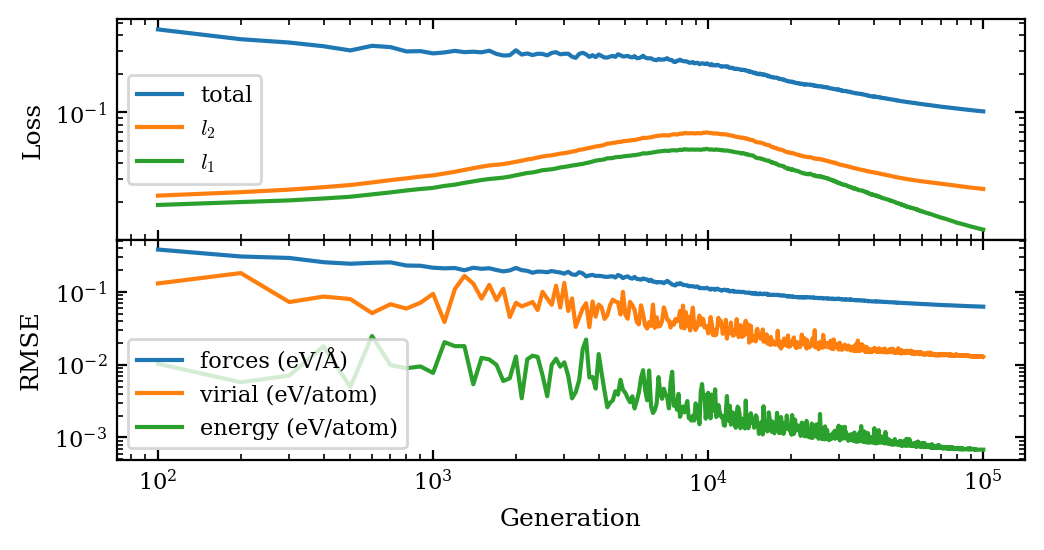

In [23]:
fig = plot_loss()
fig.savefig('figures/Loss_and_RMSE.pdf', bbox_inches='tight')

We can also inspect predicted vs target values for energy, force, viral and stress.

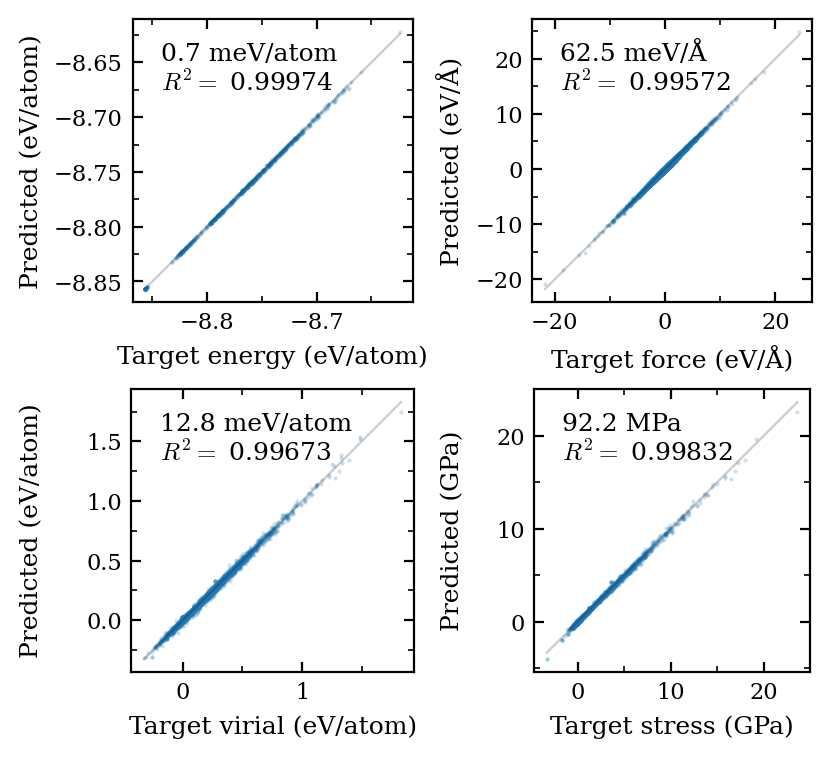

In [24]:
fig = plot_parity()
fig.savefig('figures/parity.pdf', bbox_inches='tight')

### 3. Build active set

With the NEP model trained, we need to build an active set to calculate extrapolation grades.

In [4]:
# Build Active Set (.asi) with MaxVol
NEP.build_active_set()

Building active set...
Calculating descriptors for 838 structures...


100%|██████████| 838/838 [00:32<00:00, 25.88it/s]


Building active set for Ba...
Maxvol Speed: 1521 iters/s
Building active set for O...
Maxvol Speed: 315 iters/s
Building active set for Ti...
Maxvol Speed: 2022 iters/s
Active set inverse saved to results/ALnep/iteration_2/active_set.asi
Active set structure saved to results/ALnep/iteration_2/active_set.xyz


In [47]:
#view(NEP.active_set_struct)

Now that we have the active set, we can calculate the extrapolation grade of all atoms.

In [11]:
NEP.assign_gamma(NEP.train_data)

Calculating descriptors for 776 structures...


100%|██████████| 776/776 [00:17<00:00, 44.87it/s]


In [9]:
def plot_gamma_model(structures, per_struct=True, width=1):
    import math
    import numpy as np
    if per_struct:
        gammas = np.array([max(structures[i].arrays["gamma"]) for i in range(len(structures))])
    else:
        gammas = np.array([gamma for struct in structures for gamma in struct.arrays["gamma"]])
    # Round gamma values to 5 decimals
    gammas = np.round(gammas, 5)
    
    print(f"Gamma range: {gammas.min()} - {gammas.max()}")

    g_min = math.floor(np.min(gammas) * 2) / 2
    g_max = math.ceil(np.max(gammas) * 2) / 2

    lf = LatexFigure()
    fig, axes = lf.create(width=width, AR=0.6, style='bands')

    for ax in axes:
        #ax.set_title('Distribution of Extrapolation Grade (gamma)')

        ax.hist(gammas, range=(g_min, g_max), bins=100,
                color='steelblue', edgecolor='black', lw=0.8, alpha=1, density=False)

        ax.set_xlabel('Extrapolation Grade ($\\gamma$)')
        if per_struct:
            ax.set_ylabel('Structures')
        else:
            ax.set_ylabel('Environments')

        ax.set_xlim(g_min, g_max)

        ax.set_yscale('log')

    return fig

Gamma range: 0.1956 - 1.0


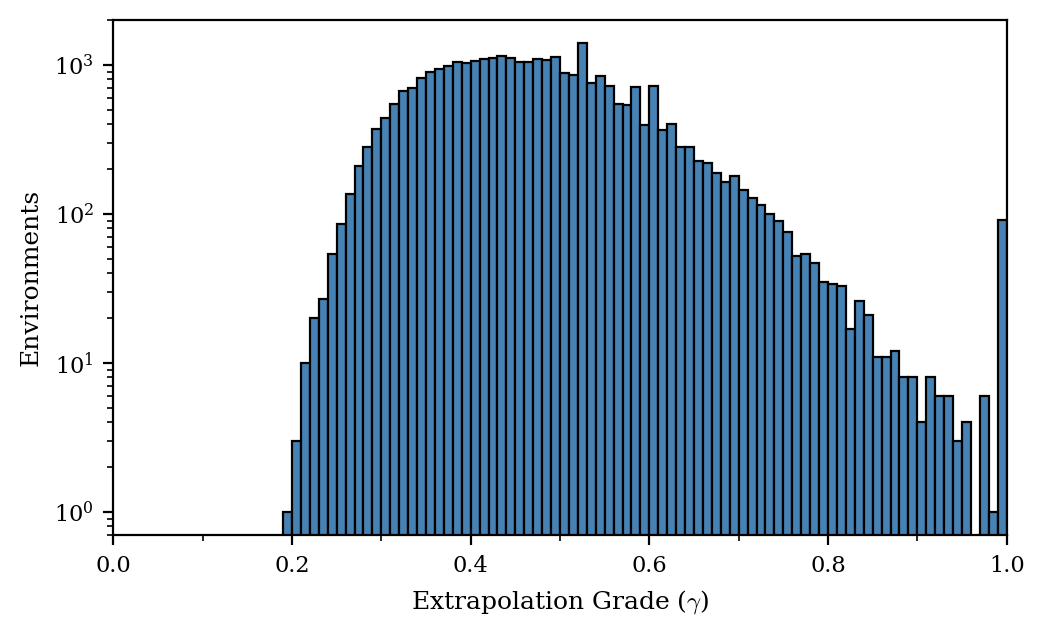

In [14]:
fig = plot_gamma_model(NEP.train_data, per_struct=False)

As expected, all structures have extrapolation bellow 1.

We now investigate strained structures

In [48]:
# Apply some strain to the active set structures and re-assign gamma to see how the extrapolation grade changes
NEP.build_active_set()
for atoms in NEP.active_set_struct:
    NEP._strain_structure(atoms, 5)


Existing active set inverse (.asi) and structures (.xyz) found. Loading...


Calculating descriptors for 68 structures...


100%|██████████| 68/68 [00:01<00:00, 49.76it/s]


Gamma range: 0.23154 - 1.85368


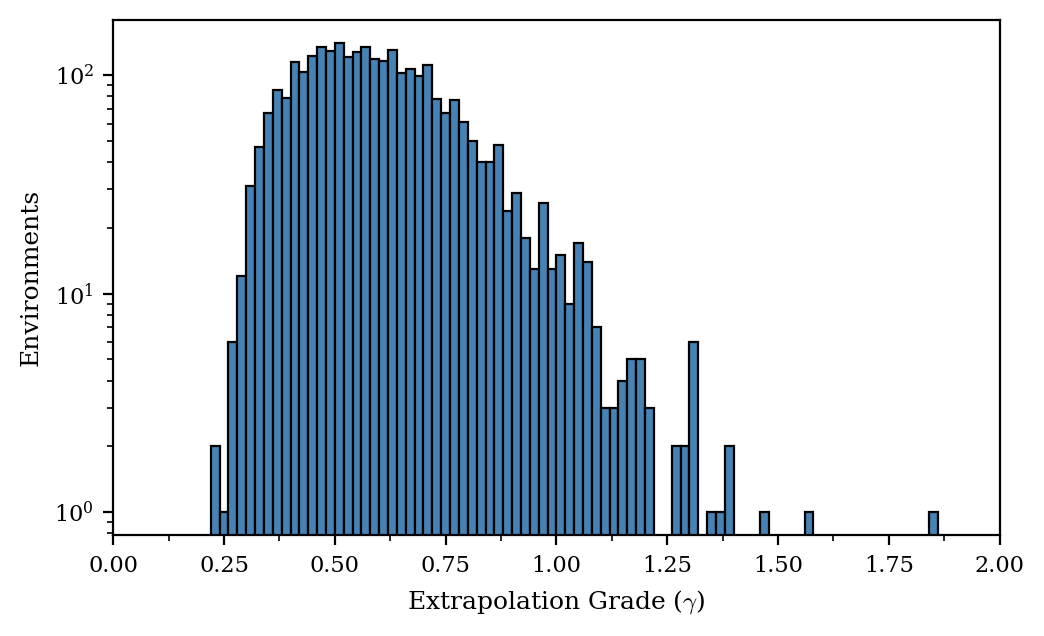

In [49]:
NEP.assign_gamma(NEP.active_set_struct)
plot_gamma_model(NEP.active_set_struct, per_struct=False)

We can now test how resilient the dataset is to larger supercells/systems.

In [ ]:
#sc_structures = [NEP.train_data[i].repeat((2, 2, 1)) for i in range(len(NEP.train_data))]

In [ ]:
NEP.assign_gamma(sc_structures)

All structures already have descriptors calculated.


Gamma range: 0.60647 - 1.74285


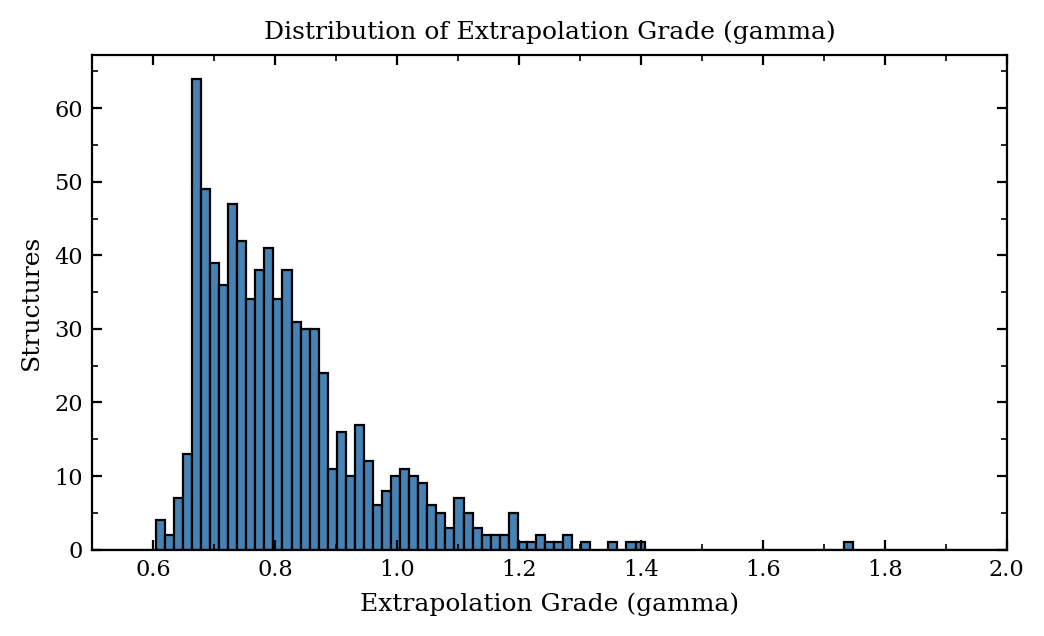

In [ ]:
plot_gamma_model(sc_structures)

These are all bellow 2, so considered a safe extrapolation.

What if we try to make thicker slabs than the model has been trained on?

In [ ]:
from src.structure import Perovskite
slab_structures = [Perovskite('BaTiO3', bulk=False, dslab=(1.5+i)).atoms.repeat((2, 2, 1)) for i in range(2, 20)]

In [ ]:
slab_descriptors = NEP._calculate_descriptors(slab_structures)

Computed descriptor matrix: (4356, 30)


Gamma range: 2.06887 - 2.06887


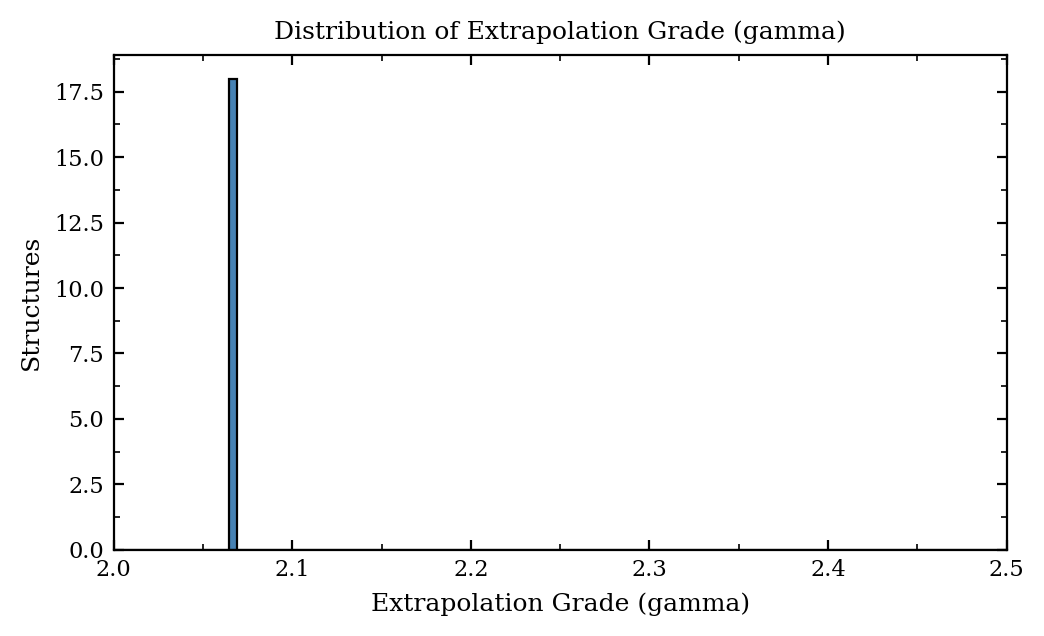

In [ ]:
NEP.assign_gamma(slab_structures, slab_descriptors)
plot_gamma_model(slab_structures)

Does not change at all. Note strain on lattice, should use relaxed slabs for lower gamma.

Now additional phonon ratteling.

In [51]:
import phonopy as ph
from src.phononASE import phonon_to_atoms
phonon = ph.load('results/ALnep/bulk.yaml')

# Produce the force constants
phonon.produce_force_constants()
# Get the force constants matrix
fc = phonon.force_constants

# Convert the phonon object to an ASE Atoms object
atoms = phonon_to_atoms(phonon, cell='super')
rattled_structures = NEP._get_rattled_structures(atoms, fc, 500, 1000)

Acoustic sum rules not enforced, squared frequencies: [0.00482294 0.00485357 0.00488422]
Imaginary modes present


Calculating descriptors for 1000 structures...


100%|██████████| 1000/1000 [00:38<00:00, 25.69it/s]


Gamma range: 0.70159 - 1.93261


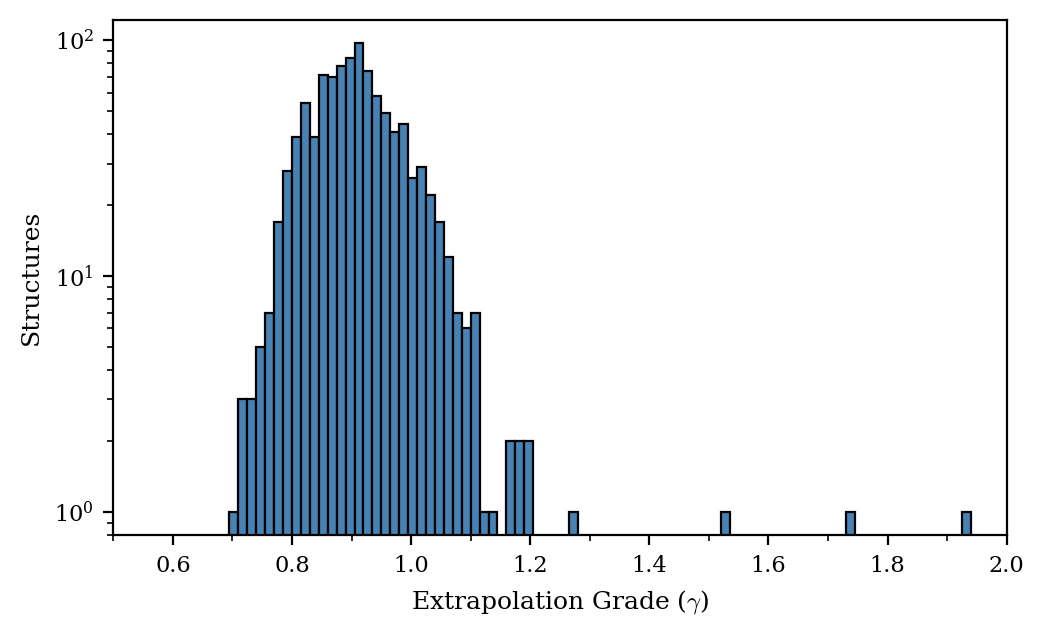

In [52]:
NEP.assign_gamma(rattled_structures)
plot_gamma_model(rattled_structures)

### 4. MD exploration

We now run MD to explore for new configurations that have high extrapolation grade.

In [45]:
# Define parameters for running MD simulations with the trained NEP model
md_params = dict(dt=1,
                 n_steps=5*1e5,
                 n_dump=1000,
                 temperatures=[100, 200, 300, 400, 500, 600])
NEP.setup_MD(**md_params)
#NEP.run_MD()       # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

      Step     Time          Energy          fmax
BFGS:    0 10:11:44     -458.938880        0.074956
BFGS:    1 10:11:44     -458.939536        0.048642
BFGS:    2 10:11:44     -458.940632        0.036447


/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.726475621142667e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.688308863507962e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.687956372039152e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor


BFGS:    3 10:11:44     -458.940905        0.034751
BFGS:    4 10:11:44     -458.941389        0.029999
BFGS:    5 10:11:44     -458.941743        0.030428
BFGS:    6 10:11:44     -458.942305        0.038296
BFGS:    7 10:11:44     -458.942641        0.024376
BFGS:    8 10:11:44     -458.942750        0.009762
BFGS:    9 10:11:44     -458.942768        0.009963


/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.687844568219989e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.687555134240147e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.687292761556065e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.693624732305654e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/p

BFGS:   10 10:11:44     -458.942778        0.010014
BFGS:   11 10:11:44     -458.942796        0.009562
BFGS:   12 10:11:44     -458.942817        0.008351
BFGS:   13 10:11:44     -458.942838        0.007646
BFGS:   14 10:11:44     -458.942859        0.007460
BFGS:   15 10:11:44     -458.942889        0.009065
BFGS:   16 10:11:44     -458.942924        0.009757
BFGS:   17 10:11:44     -458.942949        0.005823


/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.697295782635509e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.714810244733986e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.698248862479229e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 4.685761094479846e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/p

BFGS:   18 10:11:44     -458.942956        0.001478
BFGS:   19 10:11:44     -458.942956        0.000204
BFGS:   20 10:11:44     -458.942956        0.000023
      Step     Time          Energy          fmax
BFGS:    0 10:11:45     -281.486849        0.024023
BFGS:    1 10:11:45     -281.486910        0.015733
BFGS:    2 10:11:45     -281.486979        0.013162
BFGS:    3 10:11:45     -281.486994        0.012539
BFGS:    4 10:11:45     -281.487063        0.008676
BFGS:    5 10:11:45     -281.487081        0.006214
BFGS:    6 10:11:45     -281.487087        0.005541
BFGS:    7 10:11:45     -281.487090        0.005325
BFGS:    8 10:11:45     -281.487099        0.004646
BFGS:    9 10:11:45     -281.487113        0.006883
BFGS:   10 10:11:45     -281.487130        0.006627
BFGS:   11 10:11:45     -281.487138        0.003098
BFGS:   12 10:11:45     -281.487139        0.000531
BFGS:   13 10:11:45     -281.487139        0.000026
      Step     Time          Energy          fmax
BFGS:    0 10:11

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.7362159409225573e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor


In [3]:
NEP.collect_MD_structures()

In [21]:
md_structures = read(os.path.join(NEP.run_dir, 'iteration_1/md/md_structures.xyz'), index=':')

In [19]:
len(md_structures)

6000

In [20]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [33]:
test = read('results/ALnep2/iteration_1/md/temp/run_003/dump.xyz', index=':')
len(test)

2000

In [ ]:
view(test)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [124]:
NEP.assign_gamma(test)

Calculating descriptors for 1000 structures...


100%|██████████| 1000/1000 [00:26<00:00, 37.92it/s]


Gamma range: 0.21438 - 1.0636


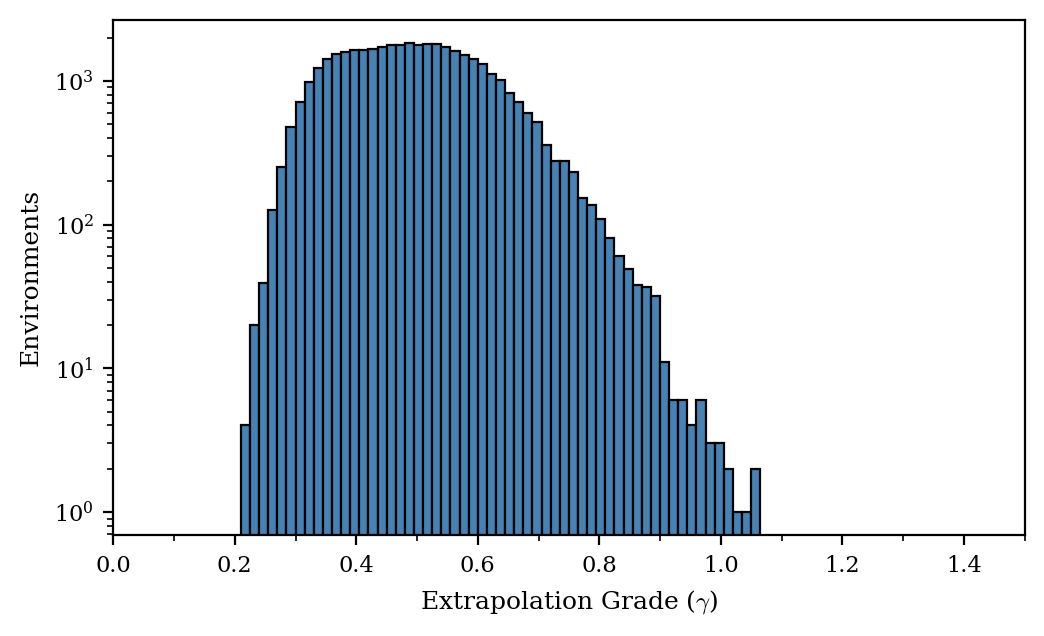

In [125]:
plot_gamma_model(test, per_struct=False)

In [61]:
# Collect structure from different MD runs
#NEP.collect_MD_structures()
md_structures = []
for temp in ['100K', '200K', '300K', '400K', '500K', '600K']:
    md_structures.extend(read(os.path.join(NEP.iter_dir, f'md_old4/Ba4O20Ti8/{temp}/dump.xyz'), ':'))
#md_structures
#md_test = md_test[-1000:]

In [13]:
md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [14]:
from ase.visualize import view
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

All structures already have descriptors calculated.
Gamma range: 0.16734 - 1.2903


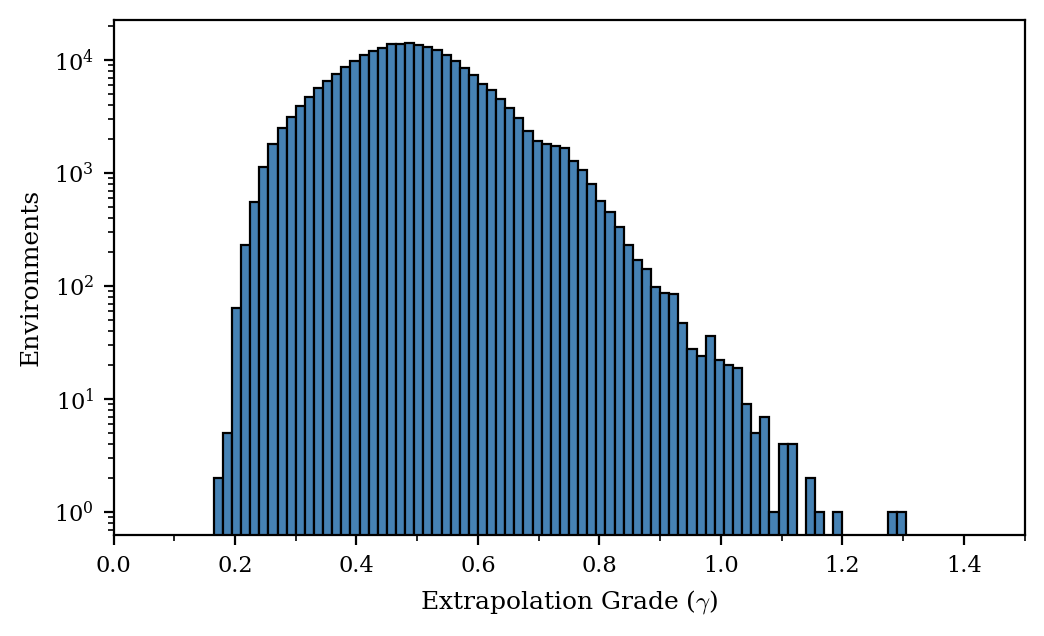

In [9]:
NEP.assign_gamma(md_structures)
plot_gamma_model(md_structures, per_struct=False)

In [ ]:
#from src.structure import wrap_to_reference
def wrap_continuous(traj, ref_atoms):
    wrapped = []

    #prev = ref_atoms.copy()
    #wrapped.append(prev)

    #cell = ref_atoms.get_cell()
    ref_scaled = ref_atoms.get_scaled_positions()

    for atoms in traj:
        new_atoms = atoms.copy()

        scaled = atoms.get_scaled_positions()

        delta = scaled - ref_scaled
        delta -= np.floor(delta + 0.5)  # wrap into [-0.5, 0.5]

        new_scaled = ref_scaled + delta

        new_atoms.set_scaled_positions(new_scaled)

        wrapped.append(new_atoms)

        # update reference
        ref_scaled = new_scaled

    return wrapped

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
with open(os.path.join(NEP.iter_dir, 'md/Ba4O20Ti8/100 K/run.in'), 'r') as f:
    run_in = f.read()

In [26]:
import numpy as np

def load_thermo(thermo_file, run_file):
    import re

    with open(run_file, 'r') as f:
        run_in = f.read()

    time_step = np.array(re.findall(r'time_step\s+(\d+\.?\d*)', run_in), dtype=float)
    #dump_thermo = int(re.findall(r'dump_thermo\s+(\d+)', run_in)[0])
    dump_thermo = np.array(re.findall(r'dump_thermo\s+(\d+)', run_in), dtype=int)
    n_steps = np.array(re.findall(r'run\s+(\d+)', run_in), dtype=int)

    N_steps = np.sum(n_steps)
    N_dumps = np.sum(n_steps // dump_thermo)

    t = np.linspace(0, N_steps*time_step, N_dumps)
    data = np.loadtxt(thermo_file)

    def _get_lattice_constants(cell):
        a = np.linalg.norm(cell[:, 0], axis=1)
        b = np.linalg.norm(cell[:, 1], axis=1)
        c = np.linalg.norm(cell[:, 2], axis=1)
        return a, b, c

    return {
        "t": t,             # time in fs
        "T": data[:, 0],    # temperature in K
        "K": data[:, 1],    # kinetic energy in eV
        "U": data[:, 2],    # potential energy in eV
        "Pxx": data[:, 3],  # pressure components in GPa
        "Pyy": data[:, 4],  
        "Pzz": data[:, 5],
        "Pyz": data[:, 6],
        "Pxz": data[:, 7],
        "Pxy": data[:, 8],
        "cell": _get_lattice_constants(data[:, 9:].reshape(-1, 3, 3))
    }

In [37]:
# read thermo.out and extract temperature and energy
thermo_file = 'results/ALnep/iteration_2/md/Ba8O24Ti8/600K/thermo.out'
run_file = 'results/ALnep/iteration_2/md/Ba8O24Ti8/600K/run.in'
thermo = load_thermo(thermo_file, run_file)

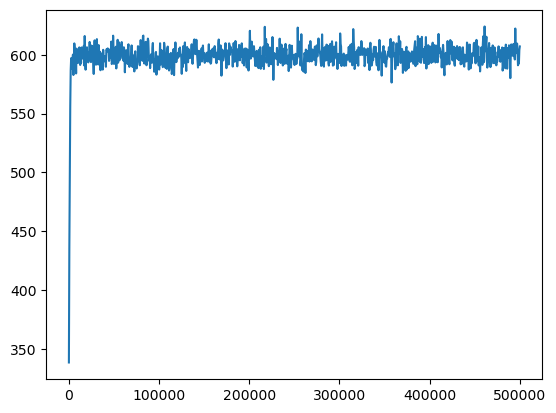

In [38]:
plt.plot(thermo['t'], thermo['T'])

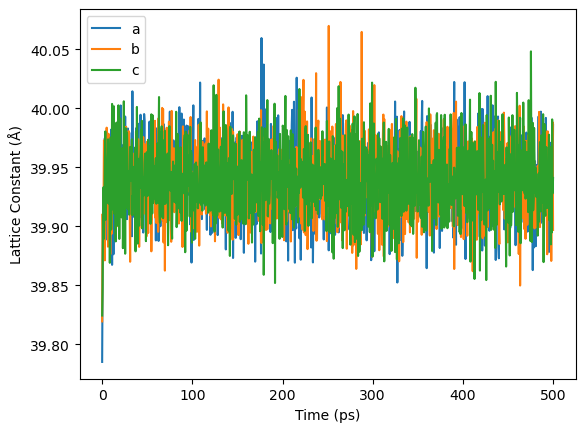

In [43]:
plt.plot(thermo['t']/1e3, thermo['cell'][0], label='a')
plt.plot(thermo['t']/1e3, thermo['cell'][1], label='b')
plt.plot(thermo['t']/1e3, thermo['cell'][2], label='c')
plt.xlabel('Time (ps)')
plt.ylabel('Lattice Constant (Å)')
plt.legend()
plt.show()

In [40]:
a= np.array([])
b = np.array([])
c = np.array([])
T = np.array([])

for temp in [100, 200, 300, 400, 500, 600]:
    thermo_file = f'results/ALnep/iteration_2/md/Ba8O24Ti8/{temp}K/thermo.out'
    run_file = f'results/ALnep/iteration_2/md/Ba8O24Ti8/{temp}K/run.in'
    thermo = load_thermo(thermo_file, run_file)
    T = np.append(T, thermo['T'])
    a = np.append(a, thermo['cell'][0])
    b = np.append(b, thermo['cell'][1])
    c = np.append(c, thermo['cell'][2])

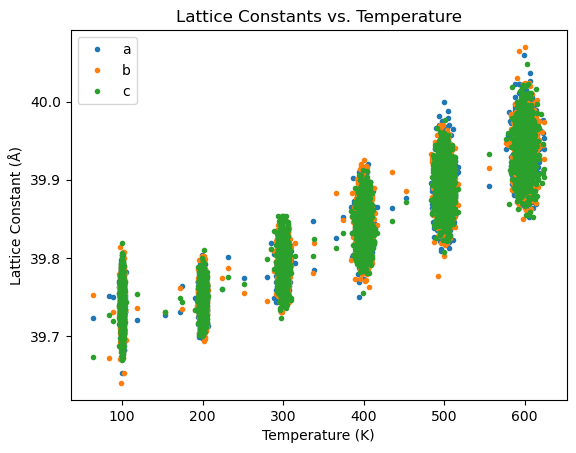

In [42]:
plt.plot(T, a, '.', label='a')
plt.plot(T, b, '.', label='b')
plt.plot(T, c, '.', label='c')
plt.xlabel('Temperature (K)')
plt.ylabel('Lattice Constant (Å)')
plt.title('Lattice Constants vs. Temperature')
plt.legend()
plt.show()

In [89]:
md_test = read(os.path.join(NEP.iter_dir, f'md/Ba4O20Ti8/100 K/dump.xyz'), ':')

In [ ]:

def get_lattice_constants(atoms):
    positions = atoms.get_positions()
    a = np.max(positions[:, 0]) - np.min(positions[:, 0])
    b = np.max(positions[:, 1]) - np.min(positions[:, 1])
    c = np.max(positions[:, 2]) - np.min(positions[:, 2])
    return a, b, c

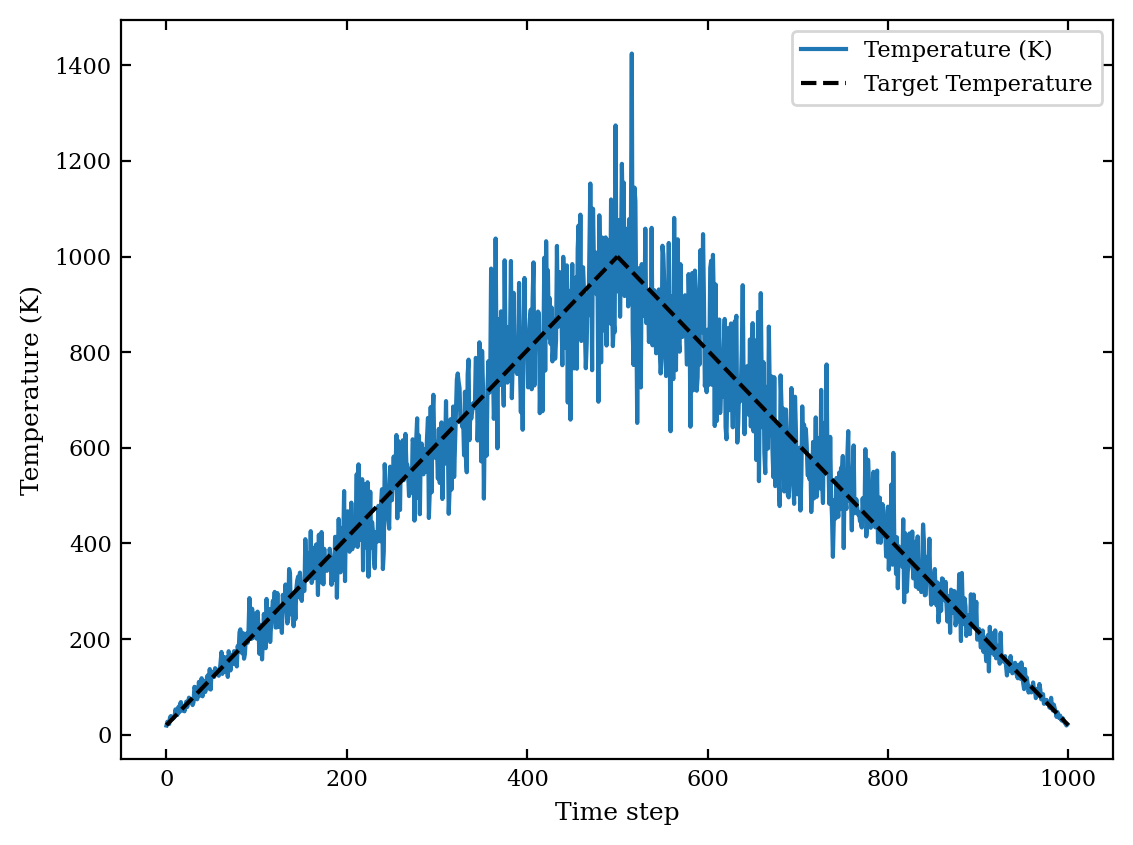

In [ ]:
plt.plot(T, label='Temperature (K)')
# Plot straight line from T0 to T1  
plt.plot([0, len(T)//2], [20, 1000], 'k--', label='Target Temperature')
plt.plot([len(T)//2, len(T)], [1000, 20], 'k--')
plt.xlabel('Time step')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()

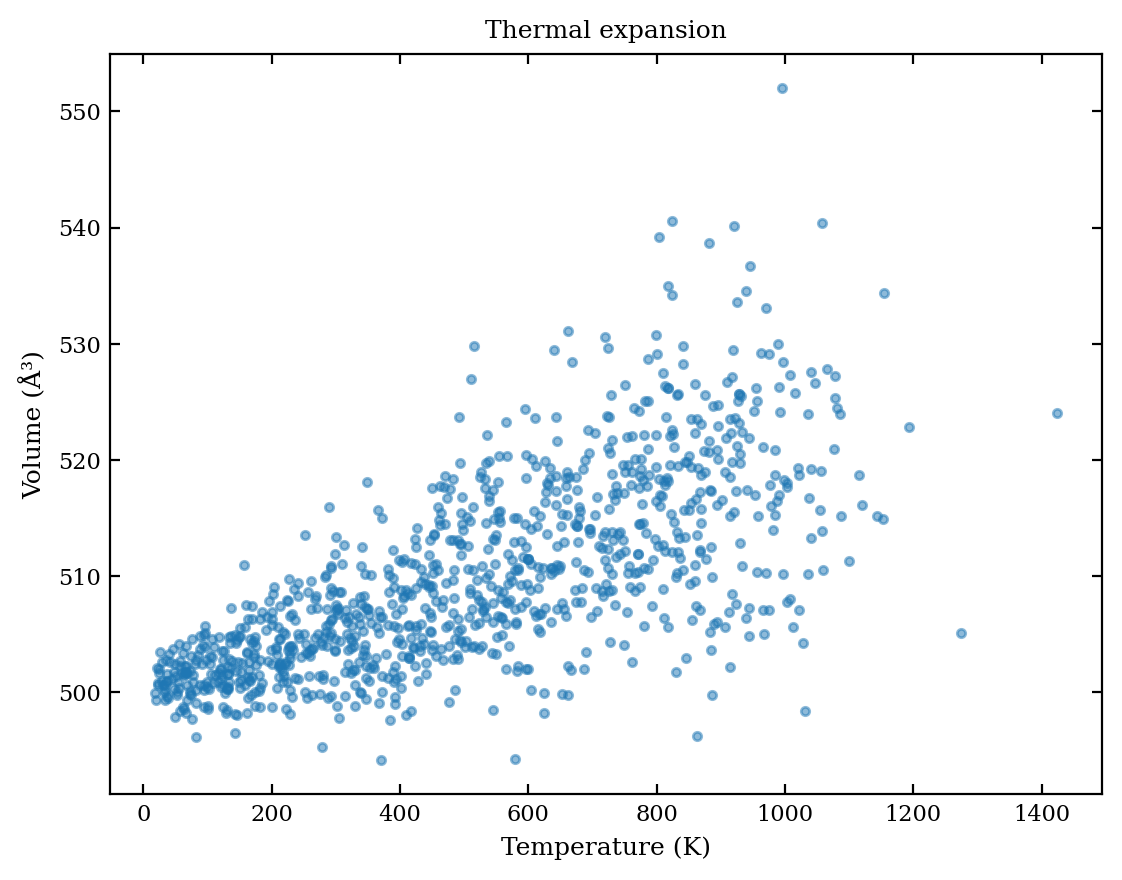

In [ ]:
def compute_volume(cell):
    return np.abs(np.linalg.det(cell))

V = np.array([compute_volume(c) for c in cell])

plt.plot(T, V, '.', alpha=0.5)
plt.xlabel("Temperature (K)")
plt.ylabel("Volume (Å³)")
plt.title("Thermal expansion")
plt.show()

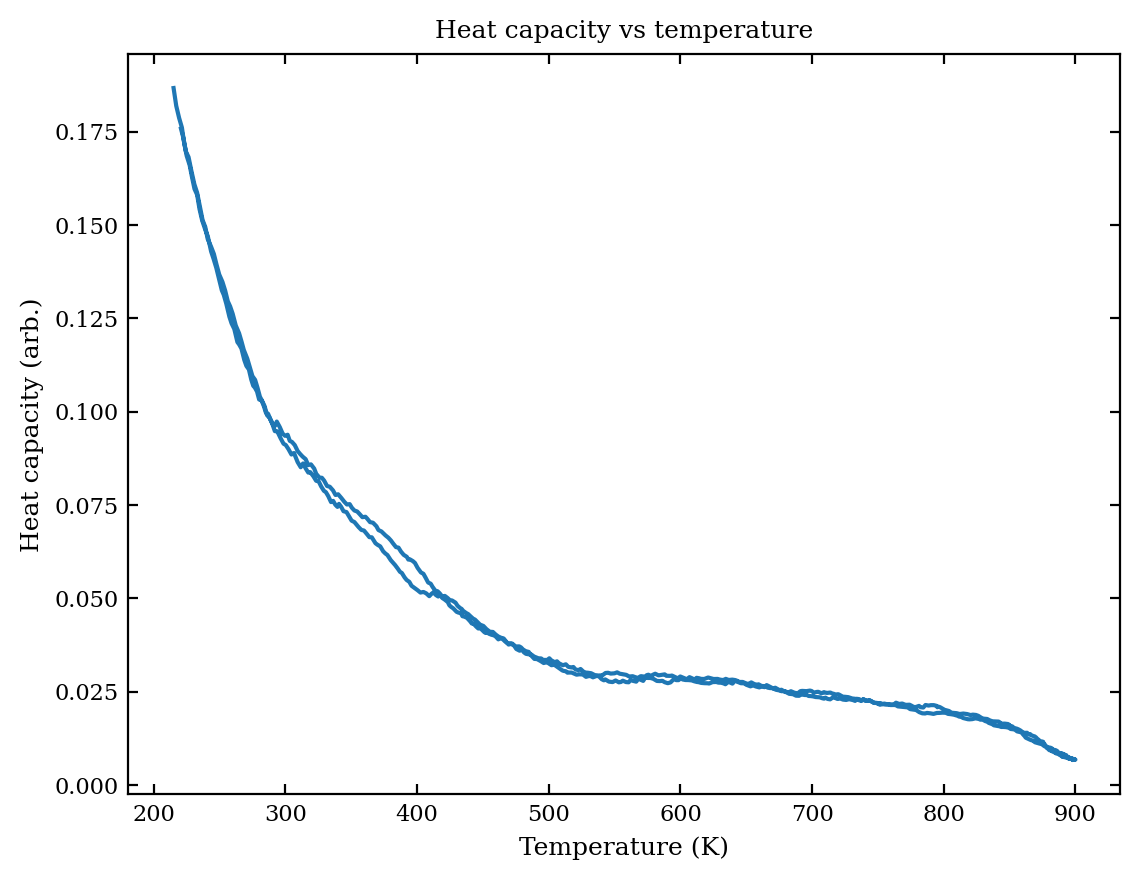

In [ ]:
kB = 8.617333262e-5  # eV/K

E = thermo["K"] + thermo["U"]

def compute_heat_capacity(T, E, window=200):
    Cv = []
    T_mid = []

    for i in range(len(T) - window):
        Ei = E[i:i+window]
        Ti = np.mean(T[i:i+window])

        varE = np.var(Ei)
        Cv.append(varE / (kB * Ti**2))
        T_mid.append(Ti)

    return np.array(T_mid), np.array(Cv)

T_mid, Cv = compute_heat_capacity(T, E)

plt.plot(T_mid, Cv)
plt.xlabel("Temperature (K)")
plt.ylabel("Heat capacity (arb.)")
plt.title("Heat capacity vs temperature")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (2000,)

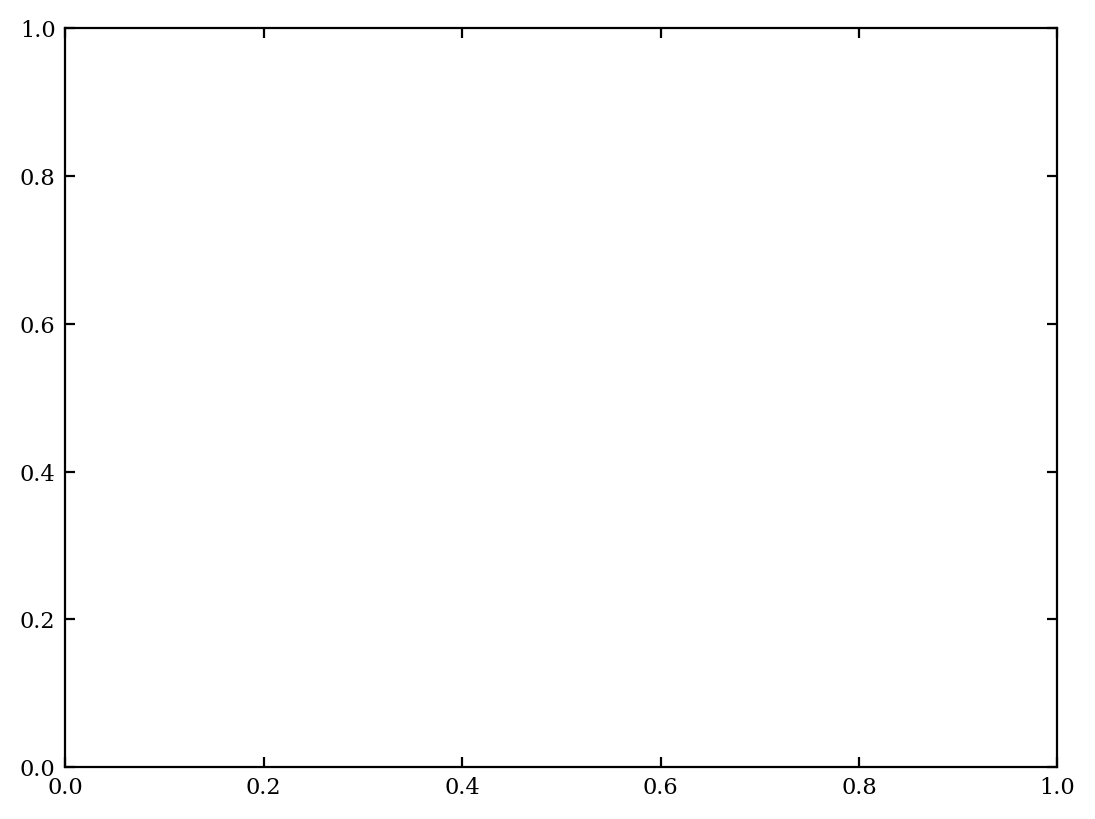

In [ ]:
Pxx = thermo["Pxx"]
Pyy = thermo["Pyy"]
Pzz = thermo["Pzz"]

anisotropy = np.std(np.vstack([Pxx, Pyy, Pzz]), axis=0)

plt.plot(T, anisotropy, '.', alpha=0.5)
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure anisotropy (GPa)")
plt.title("Symmetry breaking signal")
plt.show()

### 5. Structure filtering

To not consider all structures obtained from MD, we can calculate extrapolation grade and filter.

All structures containing no atoms/environments with gamma > gamma_th are removed.

In [22]:
#md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [30]:
md_structures = read('results/ALnep2/iteration_1/md/temp/run_002/dump.xyz', index=':')

In [ ]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

All structures already have descriptors calculated.
Gamma range: 0.19352 - 4.83577


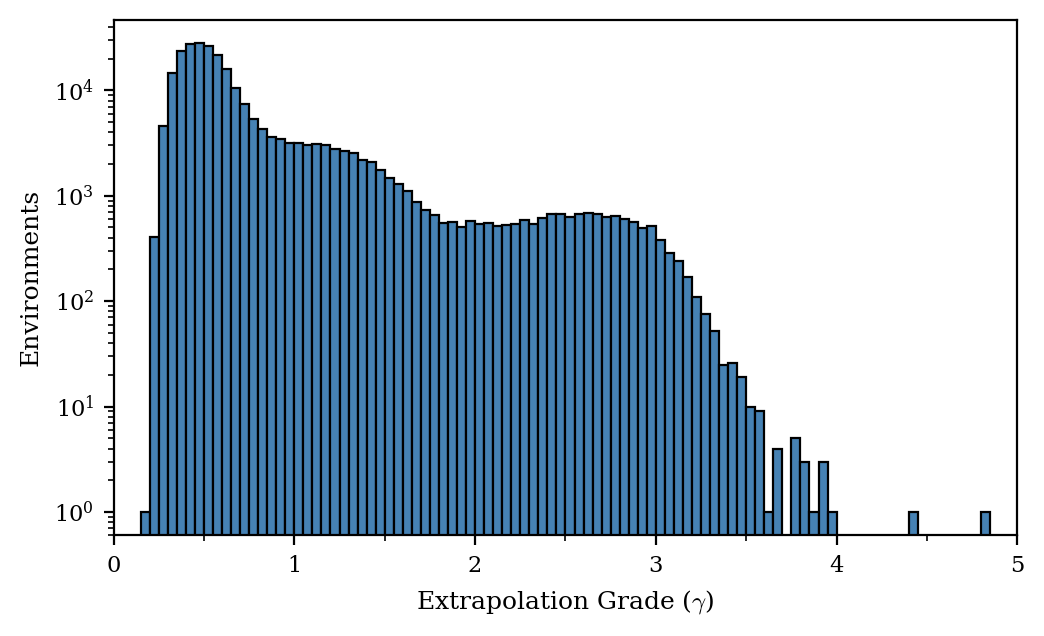

In [18]:
NEP.assign_gamma(md_structures)
plot_gamma_model(md_structures, per_struct=False)

In [19]:
# Load the collected structures and filter them based on the gamma threshold
#structures = read(os.path.join(NEP.iter_dir, "md/md_structures.xyz"), index=":")
NEP.filter_structures(md_structures, gamma_th=2)

Filtering out structures with gamma < 2...
Calculating descriptors for structures...
All structures already have descriptors calculated.
Found 1523 structures with gamma > 2.


In [ ]:
def run_MD_sim(atoms, temp=300, n_steps=5000):

    from calorine.calculators import CPUNEP
    from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
    from ase.md.langevin import Langevin
    from ase import units

    atoms.calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

    MaxwellBoltzmannDistribution(atoms, temperature_K=temp)

    # 4. Set up MD (Langevin thermostat)
    dyn = Langevin(
        atoms,
        timestep=1.0 * units.fs,
        temperature_K=temp,
        friction=0.01
    )

    dyn.attach(lambda: write('results/test/md/md.xyz', atoms, append=True), interval=100)
    dyn.run(n_steps)

In [ ]:
for i in range(15):
    atoms = read(os.path.join(NEP.iter_dir, f"md/run_{i+1:03d}/model.xyz"))
    run_MD_sim(atoms, temp=700, n_steps=10000)


KeyboardInterrupt: 

In [ ]:
md_structures = read("results/test/md/md.xyz", index=":")

In [ ]:
#view(md_structures)

In [ ]:
md_descriptors = NEP._calculate_descriptors(md_structures)

Computed descriptor matrix: (15320, 30)


Gamma range: 0.61003 - 1.18177


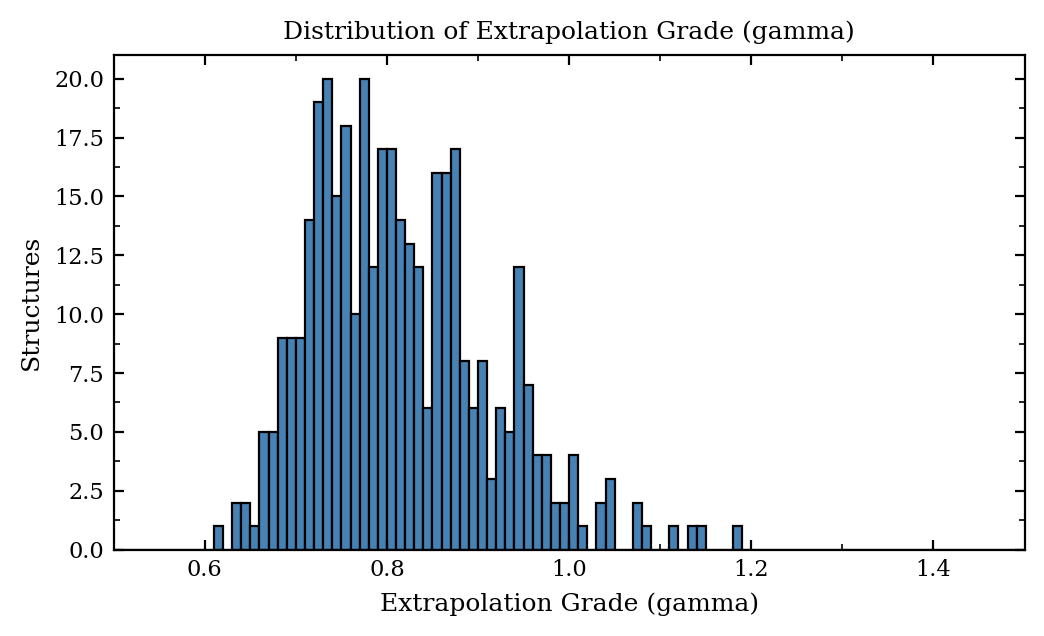

In [ ]:
NEP.assign_gamma(md_structures, md_descriptors)
plot_gamma_model(md_structures)

### 6. Diversity selection

Since we do not wish to perform DFT on all high-gamma structures, diversity selection is performed.

This ensures that only structures with atoms contributing with new basis vectors in the active set are included.

By doing this, only the most diverse environments are included.

In [3]:
# Read high gamma structures and select based on diversity (MaxVol)
structures = read(os.path.join(NEP.iter_dir, "large_gamma.xyz"), index=":")
#len(structures)
NEP.select_structures(structures, batch_size=40)


Performing diversity selection with MaxVol
Calculating descriptors for 776 structures...


100%|██████████| 776/776 [00:36<00:00, 21.53it/s]


Building active set for Ba...
Maxvol Speed: 21509 iters/s
Batch 0: adding 30 envs. 
Maxvol Speed: 34663 iters/s
Batch 1: adding 24 envs. 
Maxvol Speed: 36751 iters/s
Batch 2: adding 15 envs. 
Maxvol Speed: 40054 iters/s
Batch 3: adding 12 envs. 
Maxvol Speed: 40642 iters/s
Batch 4: adding 12 envs. 
Maxvol Speed: 42601 iters/s
Batch 5: adding 9 envs. 
Maxvol Speed: 32430 iters/s
Batch 6: adding 9 envs. 
Maxvol Speed: 31855 iters/s
Batch 7: adding 6 envs. 
Maxvol Speed: 41873 iters/s
Batch 8: adding 4 envs. 
Maxvol Speed: 33554 iters/s
Batch 9: adding 6 envs. 
Maxvol Speed: 36838 iters/s
Batch 10: adding 6 envs. 
Maxvol Speed: 30878 iters/s
Batch 11: adding 7 envs. 
Maxvol Speed: 43240 iters/s
Batch 12: adding 6 envs. 
Maxvol Speed: 28597 iters/s
Batch 13: adding 1 envs. 
Maxvol Speed: 15534 iters/s
Batch 14: adding 6 envs. 
Maxvol Speed: 22919 iters/s
Batch 15: adding 0 envs. 
Maxvol Speed: 31655 iters/s
Batch 16: adding 0 envs. 
Maxvol Speed: 34379 iters/s
Batch 17: adding 0 envs. 
Max

In [14]:
selected_structures = read(os.path.join(NEP.iter_dir, "newdata.xyz"), index=':')

In [36]:
view(selected_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [4]:
len(selected_structures)

62

In [5]:
NEP.update_dataset()

Sucessfully added 62 structures to train.xyz
Total structures in train.xyz: 838


In [10]:
NEP.run_dir

'results/ALnep'

In [83]:
structures = read(os.path.join(NEP.run_dir, 'iteration_2/train.xyz'), index=':')

In [54]:
structures = NEP.train_data

In [84]:
NEP.assign_gamma(structures)

Calculating descriptors for 838 structures...


100%|██████████| 838/838 [00:19<00:00, 42.49it/s]


In [85]:
def calculate_dE_dF(structures):
    from calorine.calculators import CPUNEP

    for structure in structures:
        try:
            E_DFT = structure.get_potential_energy()
            F_DFT = structure.get_forces().copy()
        except RuntimeError:
            continue
        calc = CPUNEP(NEP.nep_txt)
        atoms = structure.copy()
        N_atoms = len(atoms)
        atoms.calc = calc
        E_ML = atoms.get_potential_energy()
        F_ML = atoms.get_forces()

        # Calculate energy error per structure
        dE = np.abs(E_DFT - E_ML)
        structure.info["dE"] = dE/N_atoms

        # Calculate the norm of the force error per structure
        dF = np.linalg.norm(F_DFT - F_ML, axis=1)
        structure.arrays["dF"] = dF

        #dFs.append(dF)
        #gammas.append(gamma)


In [86]:
calculate_dE_dF(structures)

In [93]:
def plot_dE_gamma(structures):
    dE = np.array([struct.info["dE"]*1e3 for struct in structures])
    gamma = np.array([max(struct.arrays["gamma"]) for struct in structures])

    lf = LatexFigure()
    fig, axes = lf.create()

    axes[0].scatter(gamma, dE, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    axes[0].axvline(1, color='k', linestyle='--', lw=0.8)
    axes[0].set_xlabel('$\\gamma$ (per structure)')
    axes[0].set_ylabel('|dE| (meV/atom)')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1e-1, 1e1)
    plt.show()

In [94]:
def plot_dF_gamma(structures, per_struct=False):

    try:
        if per_struct:
            gammas = np.array([max(structures[i].arrays["gamma"]) for i in range(len(structures))])
            dFs = np.array([max(structures[i].arrays["dF"]) for i in range(len(structures))])
        else:
            gammas = np.array([gamma for struct in structures for gamma in struct.arrays["gamma"]])
            dFs = np.array([dF for struct in structures for dF in struct.arrays["dF"]])
    except Exception:
        print(f"Missing 'gamma' or 'dF' arrays in structures. Make sure to run calculate_dE_dF() first and that the structures have been assigned gamma values.")
        return

    lf = LatexFigure()
    fig, axes = lf.create()

    axes[0].scatter(gammas, dFs, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    axes[0].axvline(1, color='k', linestyle='--', lw=0.8)
    axes[0].set_xlabel('$\\gamma$ (per structure)' if per_struct else '$\\gamma$ (per atom)')
    axes[0].set_ylabel('|dF| (eV/Å)')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlim(1e-1, 1e1)
    plt.show()
    #axes[0].set_ylim(1e-10, 1e1)

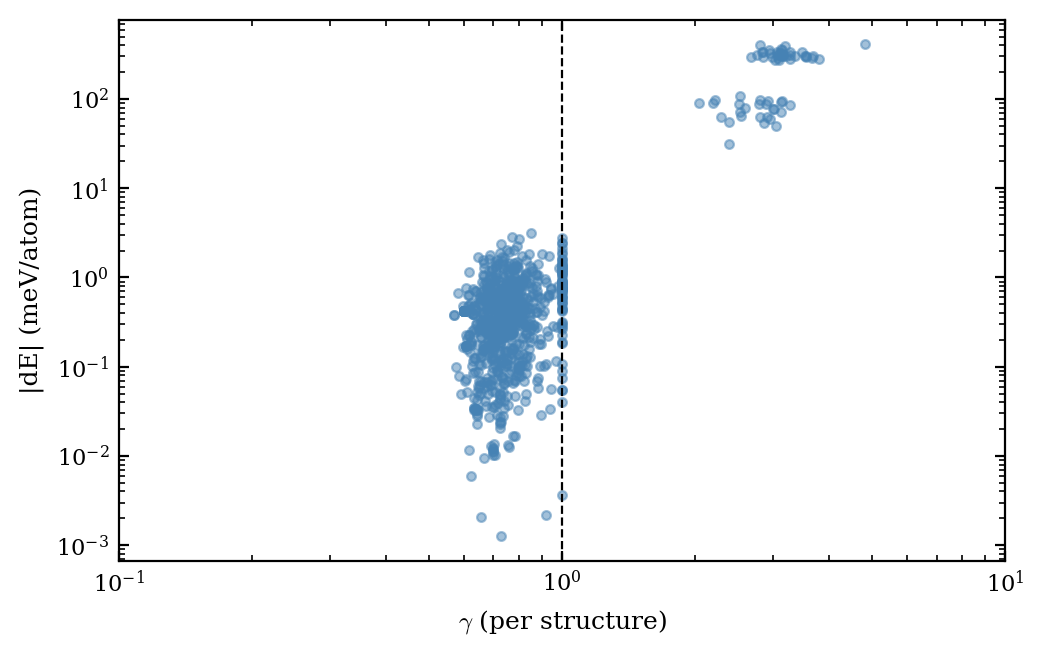

In [95]:
plot_dE_gamma(structures)

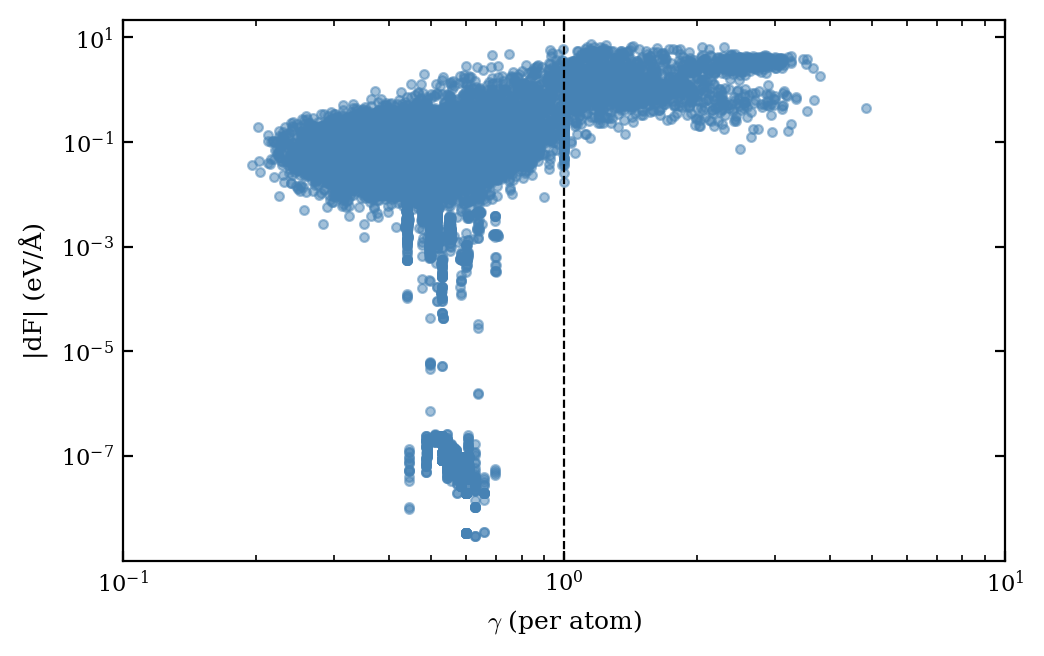

In [96]:
plot_dF_gamma(structures, per_struct=False)

Calculating descriptors for 838 structures...


100%|██████████| 838/838 [00:19<00:00, 43.45it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (838,) + inhomogeneous part.

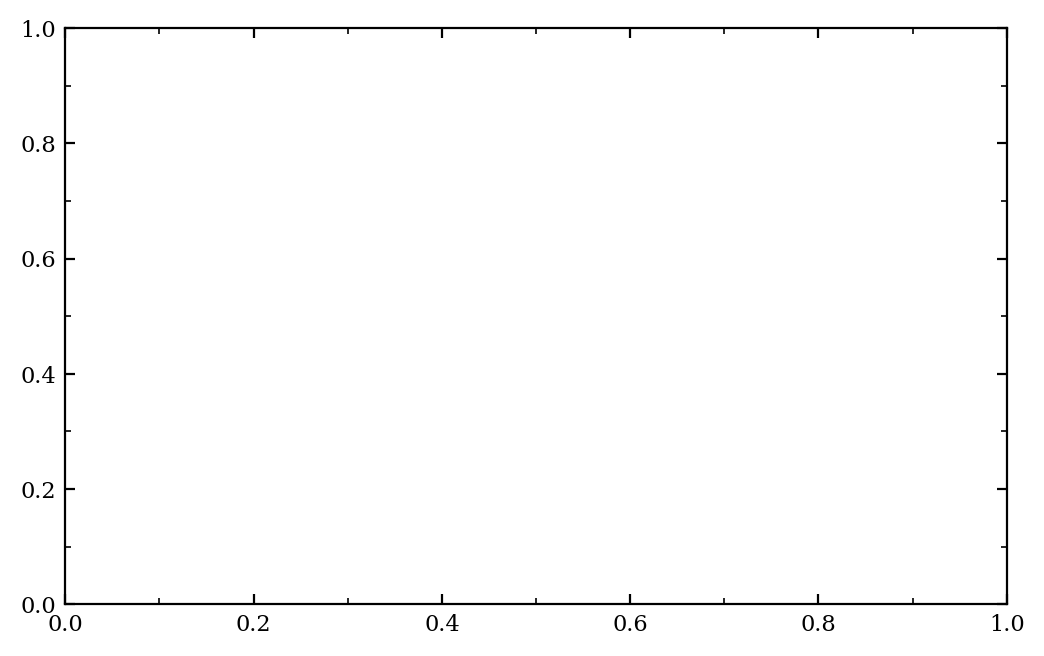

In [12]:
NEP.assign_gamma(NEP.train_data)
plot_dF_gamma(NEP.train_data)

In [ ]:
import phonopy as ph
from src.phononASE import phonon_to_atoms
phonon = ph.load('results/MLtest/BaTiO3.yaml')

# Produce the force constants
phonon.produce_force_constants()
# Get the force constants matrix
fc = phonon.force_constants

# Convert the phonon object to an ASE Atoms object
atoms = phonon_to_atoms(phonon, cell='super')
new_structures = NEP._get_rattled_structures(atoms, fc, 300, 1000)

Acoustic sum rules not enforced, squared frequencies: [0.00482294 0.00485357 0.00488422]
Imaginary modes present


In [ ]:
new_structures = [NEP.train_data[i].repeat((2, 2, 2)) for i in range(len(NEP.train_data))]

In [ ]:
from ase.visualize import view
view(new_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
NEP.filter_structures(new_structures, gamma_th=2)

Filtering out structures with gamma < 2...
Calculating descriptors for structures...
Computed descriptor matrix: (40000, 30)
Found 703 structures with gamma > 2.


In [ ]:
filtered_structures = read('results/MLtest/iteration_1/large_gamma.xyz', index=':')

In [ ]:
NEP.select_structures(filtered_structures)

Performing diversity selection with MaxVol
Computed descriptor matrix: (33960, 30)
Performing MaxVol for type 0...
Maxvol Speed: 3150 iters/s
Performing MaxVol for type 1...
Maxvol Speed: 708 iters/s
Performing MaxVol for type 2...
Maxvol Speed: 2800 iters/s
Found 70 filtered structures.


In [ ]:
selected_structures = read('results/MLtest/iteration_1/newdata.xyz', index=':')

In [ ]:
from ase.visualize import view
view(selected_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
selected_structures[0].arrays["gamma"]

array([7.98459161, 0.64577987, 1.09839168, 0.66486749, 0.64219275,
       0.95533611, 0.5669056 , 0.7393601 , 0.59651215, 0.90349156,
       0.55610104, 0.41381781, 0.82241194, 1.25364715, 0.88207511,
       0.87662537, 0.65588566, 1.05112227, 0.84457924, 1.06276169,
       0.59676655, 1.07429597, 0.62982156, 0.66234556, 0.48279781,
       0.68901255, 0.72202063, 0.39778553, 1.01825688, 0.98255694,
       0.71552915, 0.45275   , 0.53090655, 2.70847324, 0.54794066,
       0.44221814, 0.40284996, 0.57034556, 0.48180711, 0.63234743])

In [ ]:
np.array(selected_structures[0].get_chemical_symbols())

array(['Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ba', 'Ti', 'Ti', 'Ti',
       'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O'], dtype='<U2')

In [ ]:
view(new_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
view(new_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [ ]:
view(new_structures[0])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
import numpy as np
#gamma_model = np.array([max(NEP.train_data[i].arrays["gamma"]) for i in range(len(NEP.train_data))])
#gamma_new_structures = np.array([max(new_structures[i].arrays["gamma"]) for i in range(len(new_structures))])
gamma_filtered_structures = np.array([max(filtered_structures[i].arrays["gamma"]) for i in range(len(filtered_structures))])
gamma_selected_structures = np.array([max(selected_structures[i].arrays["gamma"]) for i in range(len(selected_structures))])
gamma_min = min(gamma_filtered_structures.min(), gamma_selected_structures.min())
gamma_max = max(gamma_filtered_structures.max(), gamma_selected_structures.max())
print(f'Min extrapolation grade across structures: {gamma_min}')
print(f'Max extrapolation grade across structures: {gamma_max}')

Min extrapolation grade across structures: 2.00304034
Max extrapolation grade across structures: 46.54833812


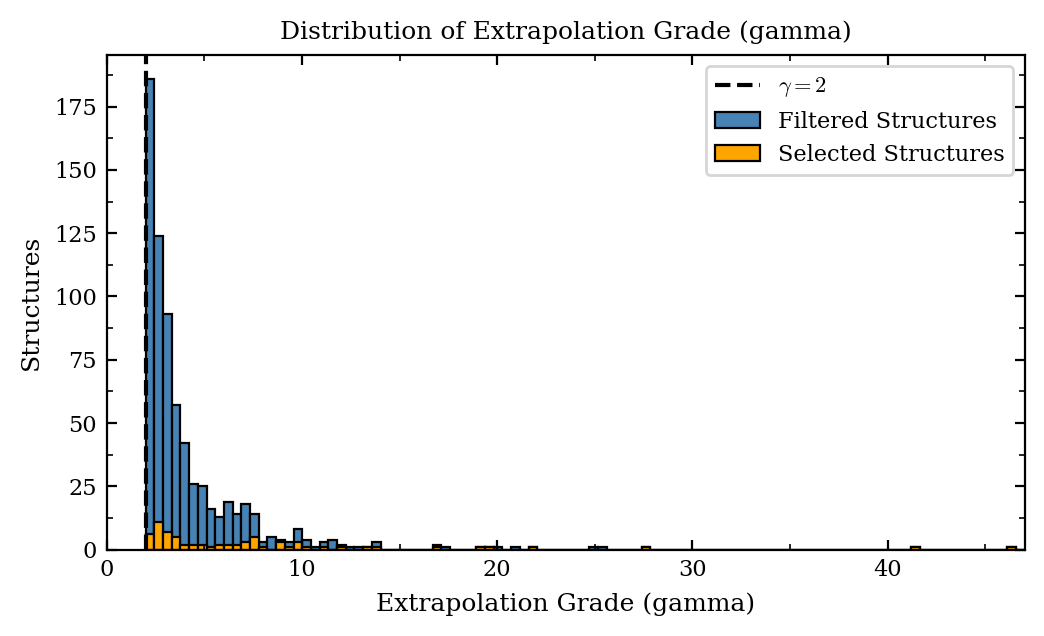

In [ ]:
# Plot distribution of gamma
import matplotlib.pyplot as plt
import math
lf = LatexFigure()

g_min = math.floor(gamma_min * 2) / 2
g_max = math.ceil(gamma_max * 2) / 2

fig, axes = lf.create(AR=0.6)

# Plot vertical line at gamma = 2
axes[0].axvline(x=2, color='black', linestyle='--', label='$\\gamma = 2$')

axes[0].hist(gamma_filtered_structures, label='Filtered Structures', range=(g_min, g_max), bins=101,
             color='steelblue', edgecolor='black', lw=0.8, alpha=1, density=False)
#axes[1].hist(gamma_filtered_structures, label='Filtered Structures', range=(0, g_max), bins=101,
#             color='green', edgecolor='black', alpha=1, density=False)
axes[0].hist(gamma_selected_structures, label='Selected Structures', range=(g_min, g_max), bins=101,
             color='orange', edgecolor='black', lw=0.8, alpha=1, density=False)
#axes[0].hist(gamma_candidates, range=(0, gamma_max), bins=101,
#             color='green', edgecolor='black', alpha=1, density=True)
#plt.hist(get_gamma(descriptors, NEP.active), bins=50, color='orange', edgecolor='black')

axes[0].set_title('Distribution of Extrapolation Grade (gamma)')
axes[0].set_xlim(0, g_max)
axes[0].set_ylabel('Structures')
axes[0].legend()

axes[0].set_xlabel('Extrapolation Grade (gamma)')

#axes[0].grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
def plot_active_set(A, idx):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    pca = PCA(n_components=2)
    A2 = pca.fit_transform(A)

    lf = LatexFigure()
    fig, axes = lf.create()
    # Plot ALL environments as a faint cloud
    axes[0].scatter(
        A2[:, 0], A2[:, 1],
        s=15,
        alpha=0.4,
        color="gray",
        label="All environments"
    )

    # Plot active set clearly
    axes[0].scatter(
        A2[idx, 0], A2[idx, 1],
        s=10,
        marker='x',
        #edgecolor="black",
        color="red",
        label="Active set"
    )
    axes[0].set_title("Active set coverage of descriptor space")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()
    #axes[0].tight_layout()
    plt.show()

In [ ]:
def check_active_set_quality(A, idx):
    import numpy as np
    import matplotlib.pyplot as plt

    sub = A[idx]
    inv = np.linalg.pinv(sub)

    # projection coefficients
    C = A @ inv  # (N, M)

    # reconstruction back in descriptor space
    A_proj = C @ sub  # (N, M)

    # relative error per atom
    residual = np.linalg.norm(A - A_proj, axis=1) / (np.linalg.norm(A, axis=1) + 1e-12)

    print(f"Mean reconstruction error: {np.mean(residual):.4e}")
    print(f"Max reconstruction error: {np.max(residual):.4e}")

    plt.hist(residual, bins=50)
    plt.title("Descriptor reconstruction error (active set quality)")
    plt.show()

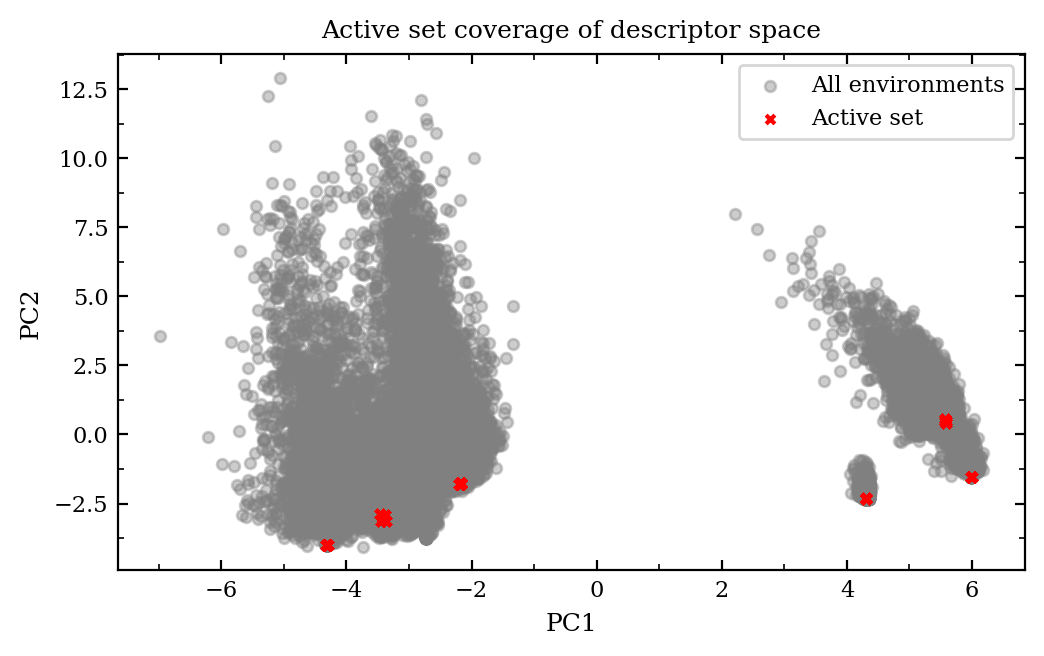

Mean reconstruction error: 5.3379e-13
Max reconstruction error: 2.0019e-12


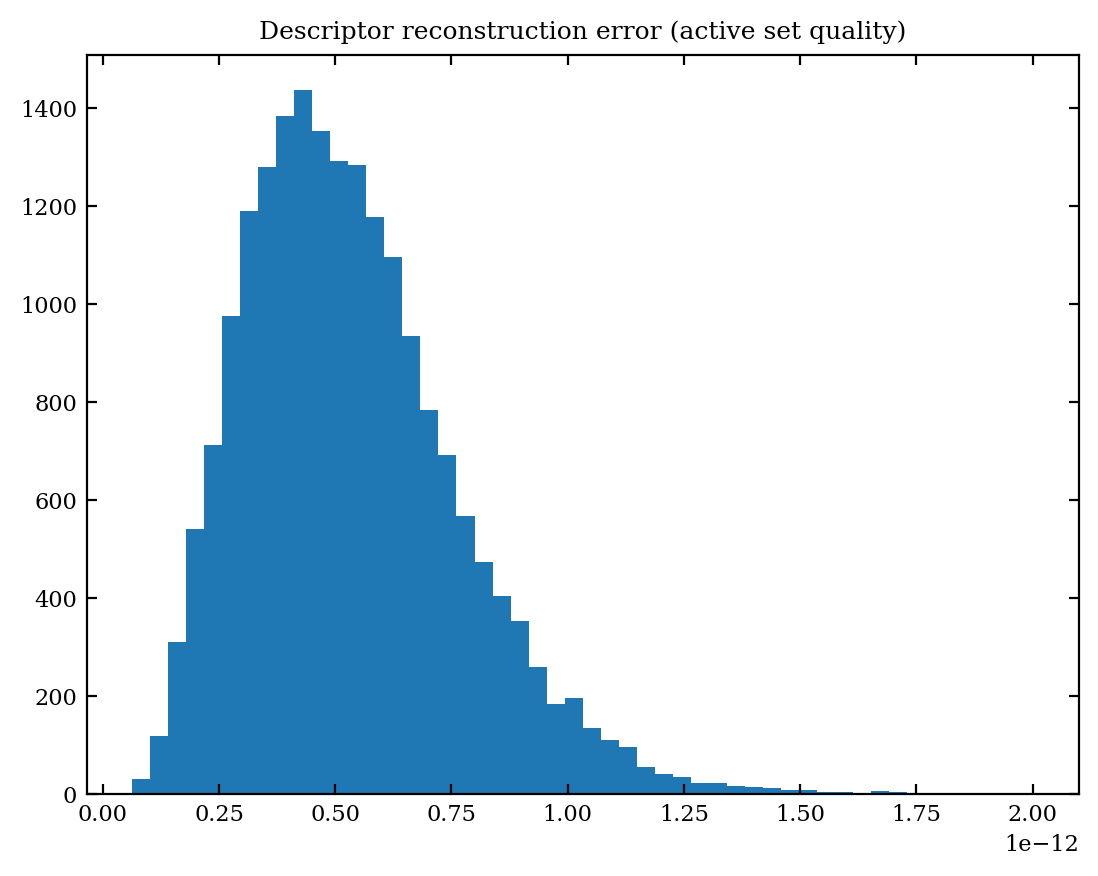

In [ ]:
plot_active_set(NEP.descriptors, NEP.active_index)
check_active_set_quality(NEP.descriptors, NEP.active_index)

In [ ]:
from ase.io import read
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure, get_force_constants

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.structure import Perovskite
perovskite = Perovskite('BaTiO3', N=2)
atoms = perovskite.atoms
calculator = CPUNEP('results/MLtest/iteration_1/nep.txt')
atoms.calc = calculator
relax_structure(atoms, fmax=0.00001)

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.7924169409636234e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.6684850377652733e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor
/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/filters.py:606: RuntimeWarning: logm result may be inaccurate, approximate err = 2.708682935440357e-13
  pos[natoms:] = self.logm(pos[natoms:]) * self.exp_cell_factor


In [ ]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.langevin import Langevin
from ase import units

MaxwellBoltzmannDistribution(atoms, temperature_K=300)

# 4. Set up MD (Langevin thermostat)
dyn = Langevin(
    atoms,
    timestep=1.0 * units.fs,
    temperature_K=300,
    friction=0.01
)

dyn.attach(lambda: write('results/MLtest/md.xyz', atoms, append=True), interval=10)
dyn.run(5000)

In [ ]:
from ase.visualize import view
view(read('results/MLtest/md.xyz', ':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

## Model predictions

### Phonon dispersions

In [ ]:
from ase.io import read
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure, get_force_constants
from src.structure import Perovskite
from src.structure import is_atom_bulk

In [101]:
from src.phononcalc import get_phonon_dispersion, get_phonon_dos, get_phonon_pdos, order_labels
from matplotlib.ticker import AutoMinorLocator

In [1]:
import sisl as si

In [2]:
band = si.get_sile('results/bulk/BaTiO3/0083/bands/BaTiO3.bands')
density = si.get_sile('results/bulk/BaTiO3/0083/bands/BaTiO3.PDOS')

Bandgap: 1.616 eV


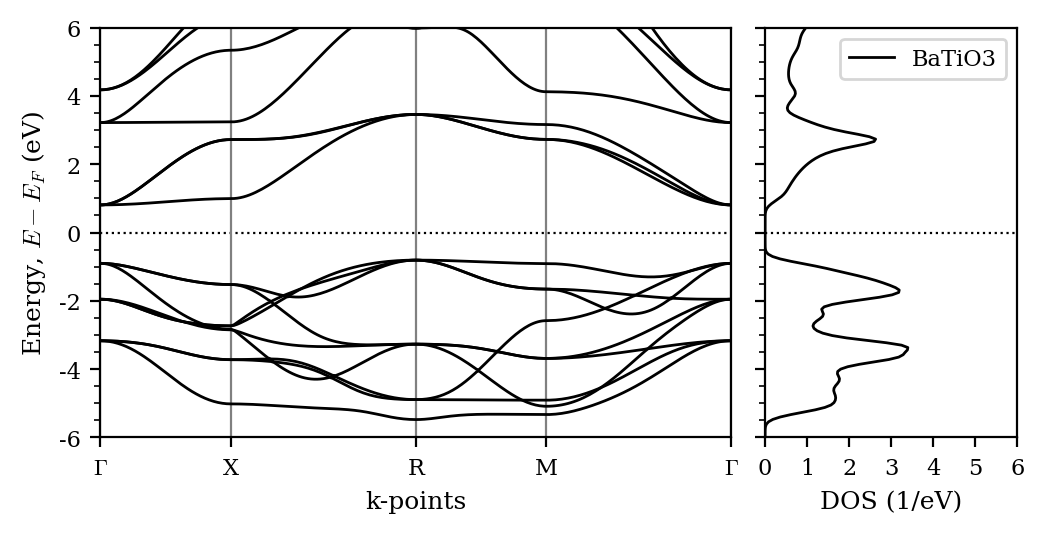

In [3]:
from src.bandscalc import plot_bandstructure
plot_bandstructure(band, density, 'BaTiO3', multiple=False)

In [191]:
sile_PDOS

In [185]:
sile_bands

In [186]:
np_bands = np.load('results/bulk/BaTiO3/GPAW/0.0/bands/BaTiO3_BS.npz', allow_pickle=True)

In [187]:
np_bands

NpzFile 'results/bulk/BaTiO3/GPAW/0.0/bands/BaTiO3_BS.npz' with keys: X, x, bands

In [189]:
# Check if object is sisl.io.siesta.bandsSileSiesta or NpzFile
if isinstance(np_bands, si.io.siesta.bandsSileSiesta):
    print("np_bands is a sisl.io.siesta.bandsSileSiesta object")
elif isinstance(np_bands, np.lib.npyio.NpzFile):
    print("np_bands is a NpzFile object")
else:
    print("np_bands is of an unexpected type:", type(np_bands))

np_bands is a NpzFile object


In [179]:
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")

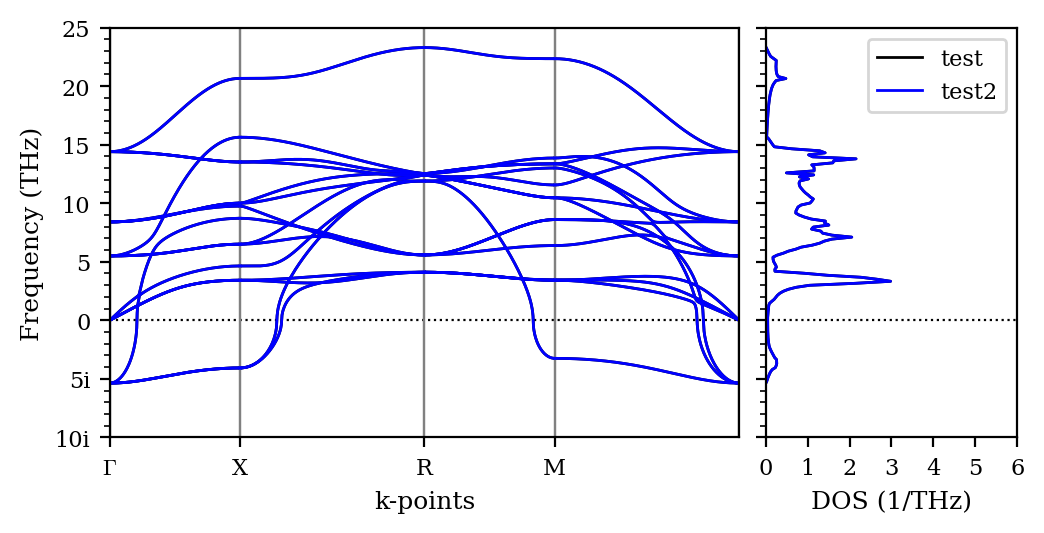

In [181]:
plot_dispersion([phonon_LCAO, phonon_LCAO], ['test', 'test2'], multiple=False)

      Step     Time          Energy          fmax
BFGS:    0 14:42:38      -44.273598        0.277107
BFGS:    1 14:42:38      -44.276634        0.234126
BFGS:    2 14:42:38      -44.284238        0.001326
BFGS:    3 14:42:38      -44.284238        0.000006
BFGS:    4 14:42:38      -44.284238        0.000000


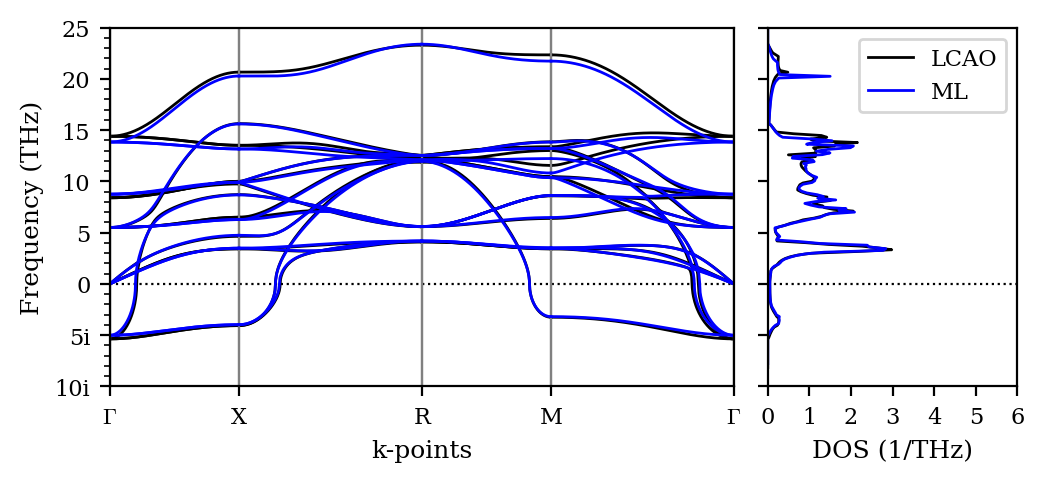

In [83]:
# Calculate phonons for the bulk unit cell structure using the trained NEP model
perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms.copy()
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")
plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=1, bulk=True)

In [9]:
strains = np.linspace(-0.01, 0.01, 5)

phonons = []
for strain in strains:
    perovskite.set_atoms(atoms)
    perovskite.apply_strain(strain)
    if strain != 0:
        NEP.relax_atoms(perovskite.atoms, strained=True)
    else:
        NEP.relax_atoms(perovskite.atoms)
    phonon = NEP.calculate_phonon(perovskite.atoms)
    phonons.append(phonon)


      Step     Time          Energy          fmax
BFGS:    0 13:38:54      -44.262664        0.216222
BFGS:    1 13:38:54      -44.263302        0.196732
BFGS:    2 13:38:54      -44.266375        0.000583
BFGS:    3 13:38:54      -44.266375        0.000002
BFGS:    4 13:38:54      -44.266375        0.000000
      Step     Time          Energy          fmax
BFGS:    0 13:38:55      -44.278867        0.108638
BFGS:    1 13:38:55      -44.279028        0.098795
BFGS:    2 13:38:55      -44.279798        0.000136
BFGS:    3 13:38:55      -44.279798        0.000000
BFGS:    4 13:38:55      -44.279798        0.000000
      Step     Time          Energy          fmax
BFGS:    0 13:38:56      -44.284238        0.000000
      Step     Time          Energy          fmax
BFGS:    0 13:38:56      -44.278908        0.109716
BFGS:    1 13:38:56      -44.279072        0.099660
BFGS:    2 13:38:56      -44.279845        0.000118
BFGS:    3 13:38:56      -44.279845        0.000000
BFGS:    4 13:38:56 

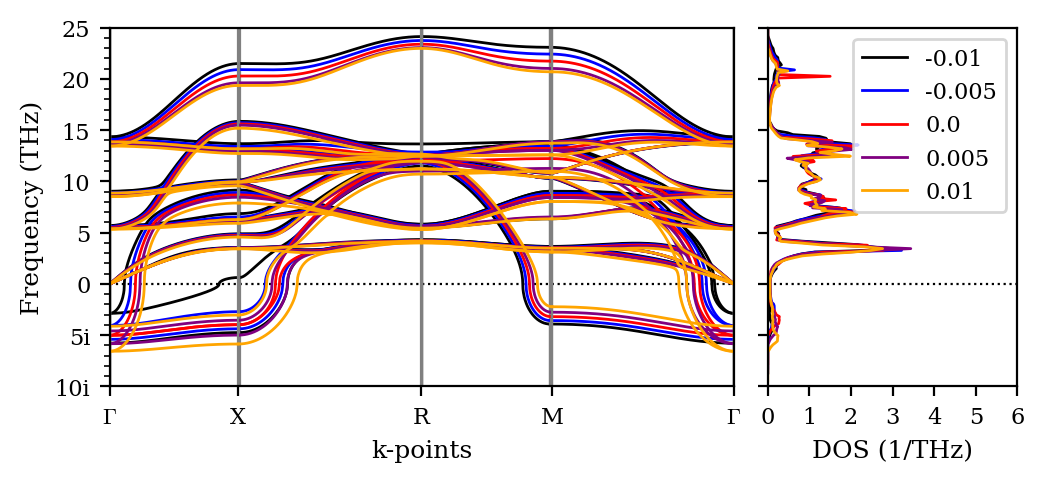

In [10]:
plot_dispersion(phonons, np.round(strains, 3), width=1, bulk=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from src.frozenphonon import get_displacement, get_unstable_mode_groups

# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = -a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier

def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'M': [0.5, 0.5, 0.0],
        'R': [0.5, 0.5, 0.5],
    }

    dd_dict = {
        'G': 0.5/n_points,
        'X': 1.5/n_points,
        'M': 3/n_points,
        'R': 5/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []
                images = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    # Get energy (eV) per atom
                    energy = supercell_disp.get_potential_energy() / len(supercell_disp)

                    amplitudes.append(amp)
                    energies.append(energy)
                    images.append(supercell_disp.copy())

                    amp += dd

                    tol = 100e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies,
                    'Structure': images
                })
                

                # Find image corresponding to the minimum energy
                min_idx = np.argmin(energies)
                atoms_min = images[min_idx].copy()
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "structure": atoms_min
                }

    return results


In [18]:
from src.phononASE import phonon_to_atoms
import pandas as pd
strains = np.linspace(-0.025, 0.025, 21)

#results = {strain: {} for strain in strains}

perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms.copy()
NEP.relax_atoms(atoms)

results = {strain: {} for strain in strains}

for strain in strains:
    perovskite.set_atoms(atoms)
    perovskite.apply_strain(strain)

    if strain != 0:
        NEP.relax_atoms(perovskite.atoms, strained=True)
    #else:
        #NEP.relax_atoms(perovskite.atoms)
    
    #latticevecs[qpoint].append(perovskite.atoms.copy().cell.diagonal())

    phonon = NEP.calculate_phonon(perovskite.atoms)
    #phonons.append(phonon)
    results[strain] = displace_imaginary_modes(phonon, n_points=201, deg=False)

# If all frequencies are 0, remove that q-point from the results
#frequencies = {q: freqs for q, freqs in frequencies.items() if any(f != 0 for f in freqs)}
#strainvals = {q: strainvals[q] for q in frequencies.keys()}


      Step     Time          Energy          fmax
BFGS:    0 13:08:39      -44.273598        0.277107
BFGS:    1 13:08:39      -44.276634        0.234126
BFGS:    2 13:08:39      -44.284238        0.001326
BFGS:    3 13:08:39      -44.284238        0.000006
BFGS:    4 13:08:39      -44.284238        0.000000
      Step     Time          Energy          fmax
BFGS:    0 13:08:39      -44.147841        0.532464
BFGS:    1 13:08:39      -44.151711        0.485058
BFGS:    2 13:08:39      -44.171134        0.029542
BFGS:    3 13:08:39      -44.171215        0.002568
BFGS:    4 13:08:39      -44.171215        0.000006
BFGS:    5 13:08:39      -44.171215        0.000000
No unstable modes found at R
      Step     Time          Energy          fmax
BFGS:    0 13:08:41      -44.173834        0.480641
BFGS:    1 13:08:41      -44.176987        0.437782
BFGS:    2 13:08:41      -44.192666        0.022253
BFGS:    3 13:08:41      -44.192712        0.002003
BFGS:    4 13:08:41      -44.192712      

In [11]:
view([results[strains[10]]['G'][0][0]['df']['Structure'][i] for i in range(541)])

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [ ]:
N = 3
mirror = False

#lf = LatexFigure()
#fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
#color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for strain in strains:
    res = results[strain]
    lf = LatexFigure()
    N = len(res.keys())
    fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    qpoints = res.keys()

    for i, q in enumerate(qpoints):

        ax = axes[i]
        color_idx = 0

        for g_id, modes in res[q].items():
            for mode_id, data in modes.items():
                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')
    plt.show()


In [19]:
qpoints = ['G', 'X', 'M']

frequencies = {q: [] for q in qpoints}
barriers    = {q: [] for q in qpoints}
structures  = {q: [] for q in qpoints}

#N = 3

#lf = LatexFigure()
#fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)

for strain in strains:
    res = results[strain]

    #qpoints = res.keys()

    for i, q in enumerate(qpoints):

        #ax = axes[i]
        freqs = []
        bars = []

        try:
            for g_id, modes in res[q].items():
                for mode_id, data in modes.items():

                    freqs.append(data["frequency"])
                    bars.append(data["barrier"])
                    #barrier = data["barrier"]
                    #ax.plot(strain, freq, '.', color='k')
        except KeyError:
            freqs = [0]
            bars = [0]
        
        frequencies[q].append(freqs)
        barriers[q].append(bars)
        structures[q].append(data["structure"])

frequencies = {q: vals for q, vals in frequencies.items() if vals}
barriers = {q: vals for q, vals in barriers.items() if vals}

In [ ]:
"""
perovskite = Perovskite('BaTiO3')
q = 'G'
for i, strain in enumerate(strains):
    perovskite.set_atoms(structures[q][i])

    if strain != 0:
        NEP.relax_atoms(perovskite.atoms, strained=True)
    else:
        NEP.relax_atoms(perovskite.atoms)
"""

In [26]:
perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms.copy()
NEP.relax_atoms(atoms)

      Step     Time          Energy          fmax
BFGS:    0 12:43:14      -44.273598        0.277107
BFGS:    1 12:43:14      -44.276634        0.234126
BFGS:    2 12:43:14      -44.284238        0.001326
BFGS:    3 12:43:14      -44.284238        0.000006
BFGS:    4 12:43:14      -44.284238        0.000000


In [29]:
perovskite = Perovskite('BaTiO3')
perovskite.set_atoms(structures['G'][10])
NEP.relax_atoms(perovskite.atoms)

      Step     Time          Energy          fmax
BFGS:    0 12:43:37      -44.292133        0.150884
BFGS:    1 12:43:37      -44.292813        0.131925
BFGS:    2 12:43:37      -44.295223        0.082775
BFGS:    3 12:43:37      -44.295445        0.087272
BFGS:    4 12:43:37      -44.296746        0.078842
BFGS:    5 12:43:37      -44.297069        0.050015
BFGS:    6 12:43:37      -44.297302        0.040704
BFGS:    7 12:43:37      -44.297413        0.032137
BFGS:    8 12:43:37      -44.297538        0.030022
BFGS:    9 12:43:37      -44.297592        0.028658
BFGS:   10 12:43:37      -44.297639        0.025645
BFGS:   11 12:43:37      -44.297718        0.024917
BFGS:   12 12:43:37      -44.297860        0.032972
BFGS:   13 12:43:37      -44.298020        0.042635
BFGS:   14 12:43:37      -44.298191        0.038752
BFGS:   15 12:43:37      -44.298354        0.045180
BFGS:   16 12:43:37      -44.298501        0.050588
BFGS:   17 12:43:37      -44.298807        0.050028
BFGS:   18 12:

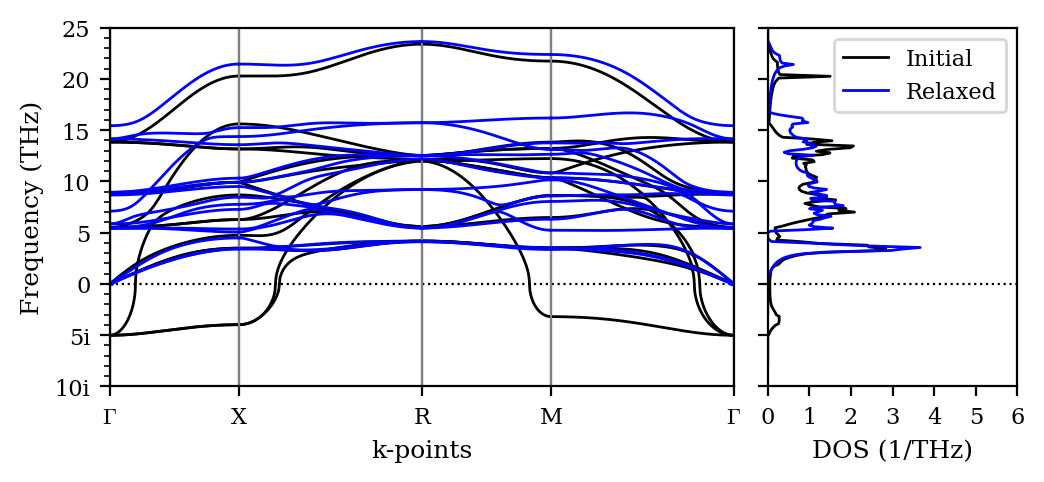

In [32]:
phonon_initial = NEP.calculate_phonon(atoms)
phonon_relaxed = NEP.calculate_phonon(perovskite.atoms)
plot_dispersion([phonon_initial, phonon_relaxed], ['Initial', 'Relaxed'], width=1, bulk=True)

In [33]:
atoms.cell.diagonal()

array([3.95963807, 3.95963807, 3.95963807])

In [34]:

perovskite.atoms.cell.diagonal()

array([3.9716264 , 3.97162658, 3.97162662])

In [297]:
from ase.visualize import view
view(perovskite.atoms)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

In [293]:
perovskite.atoms

Atoms(symbols='BaTiO3', pbc=True, cell=[[3.9716264040821105, -0.0063053603341054875, 0.006305287937462007], [-0.006221545440812008, 3.971626584798669, -0.006276252472098509], [0.006221715276678214, -0.0062509078333729175, 3.971626619109268]], calculator=CPUNEP(...))

In [ ]:
def plot_imag_freq(strains, y_vals, y_unit='THz'):

    N = len(y_vals.keys())

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
    #fig.set_constrained_layout_pads(wspace=0, w_pad=0)

    def _plot_by_degeneracy(ax, strains, y_vals):

        strains = np.array(strains)

        def _group_by_degeneracy(y_vals):

            y_vals_grouped = []

            for strain, y_val in zip(strains, y_vals):
                if len(y_val) == 1:
                    if strain == 0:
                        # Duplicate
                        pair = [y_val[0], y_val[0]]
                    else:
                        pair = [y_val[0], 0]
                else:
                    pair = y_val

                # optional symmetry flip
                if strain < 0:
                    pair = pair[::-1]

                y_vals_grouped.append(pair)

            return np.array(y_vals_grouped)
        
        try:
            y_vals_grouped = np.array(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            ax.plot(strains * 100, y_vals_grouped, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_vals_grouped, '.', markersize=2, color='k')
        
        except Exception:
            y_vals_grouped = _group_by_degeneracy(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            y_lower = y_vals_grouped[:, 0]
            y_upper = y_vals_grouped[:, 1]

            ax.plot(strains * 100, y_lower, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_upper, '-', lw=1, color='blue', label='out-of-plane')
            ax.plot(strains * 100, y_lower, '.', markersize=2, color='k')
            ax.plot(strains * 100, y_upper, '.', markersize=2, color='k')
        
        ax.set_xlim(strains[0] * 100, strains[-1] * 100)
        ax.legend()

    for i, qpoint in enumerate(y_vals.keys()):
        _plot_by_degeneracy(
            axes[i],
            strains,
            y_vals[qpoint]
        )

        axes[i].set_xlabel('Bi-axial strain (%)')

        if qpoint == 'G':
            axes[i].set_title(f'$\Gamma$ point')
        else:
            axes[i].set_title(f'{qpoint} point')

    if y_unit == 'THz':
        axes[0].set_ylabel('Frequency (THz)')
    elif y_unit == 'meV':
        axes[0].set_ylabel('$\\Delta$ Energy (meV/u.c.)')
    axes[0].set_ylim(None, -0.1)
    
    plt.show()

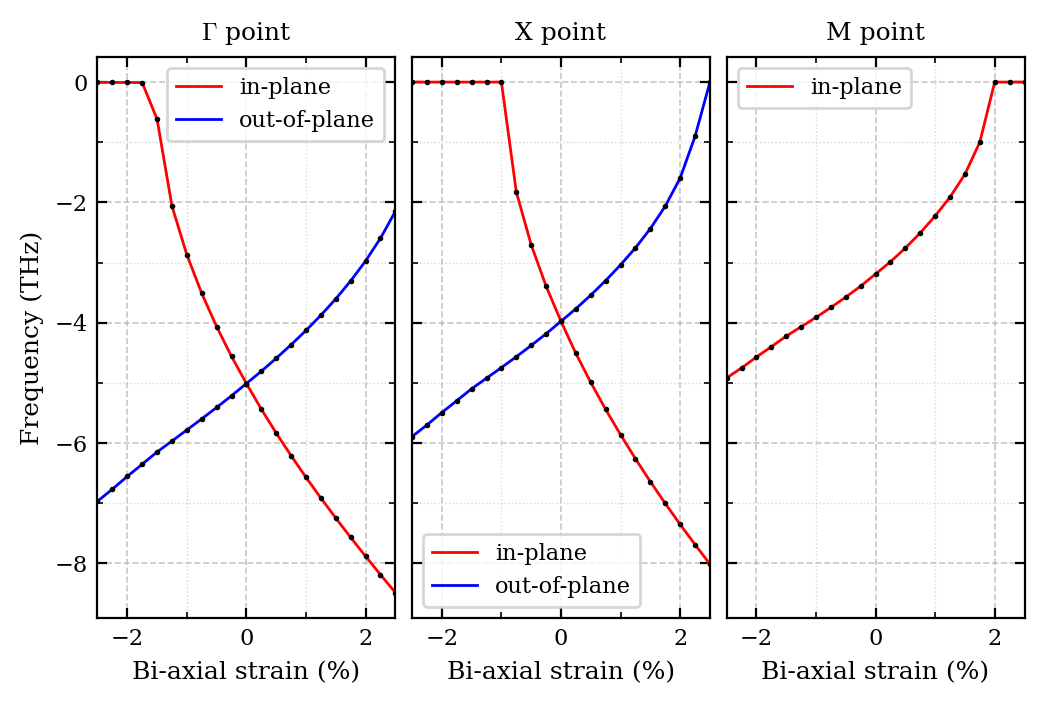

In [24]:
plot_imag_freq(strains, frequencies)

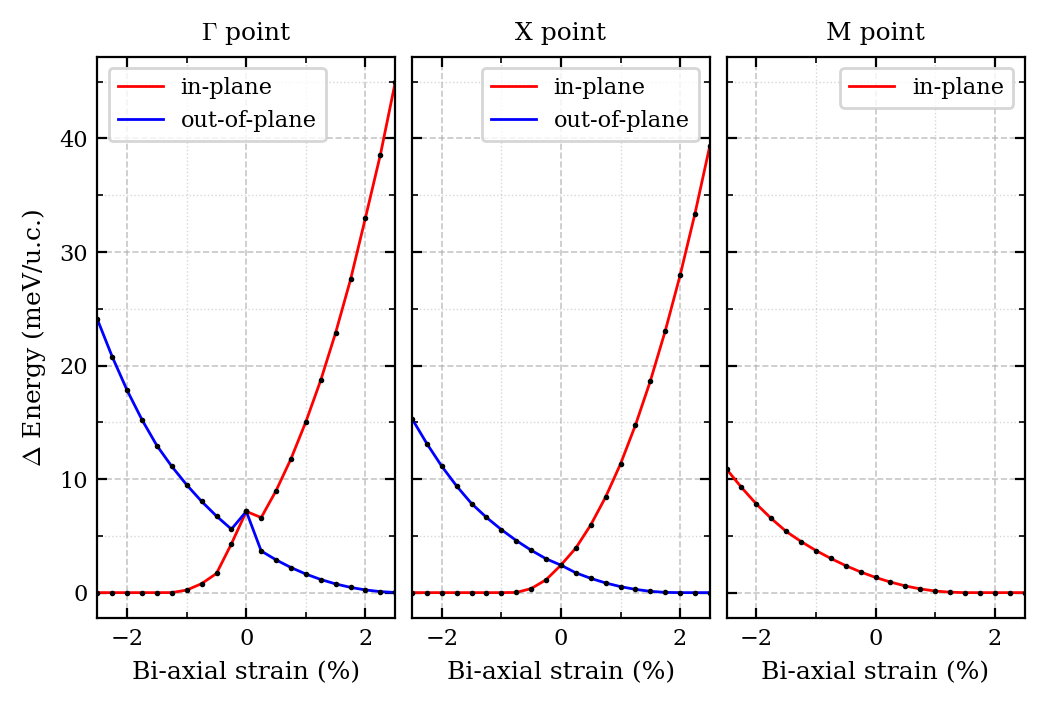

In [25]:
plot_imag_freq(strains, barriers, y_unit='meV')

      Step     Time          Energy          fmax
BFGS:    0 12:39:27      -69.744048        2.366350
BFGS:    1 12:39:27      -69.954789        1.565418
BFGS:    2 12:39:27      -70.213516        0.862726
BFGS:    3 12:39:27      -70.253739        0.755621
BFGS:    4 12:39:27      -70.363975        0.103170
BFGS:    5 12:39:27      -70.365079        0.112287
BFGS:    6 12:39:28      -70.368243        0.120995
BFGS:    7 12:39:28      -70.371409        0.115444
BFGS:    8 12:39:28      -70.373765        0.087144
BFGS:    9 12:39:28      -70.374318        0.028548
BFGS:   10 12:39:28      -70.374364        0.003329
BFGS:   11 12:39:28      -70.374366        0.000211
BFGS:   12 12:39:28      -70.374366        0.000022
BFGS:   13 12:39:28      -70.374366        0.000001
BFGS:   14 12:39:28      -70.374366        0.000000


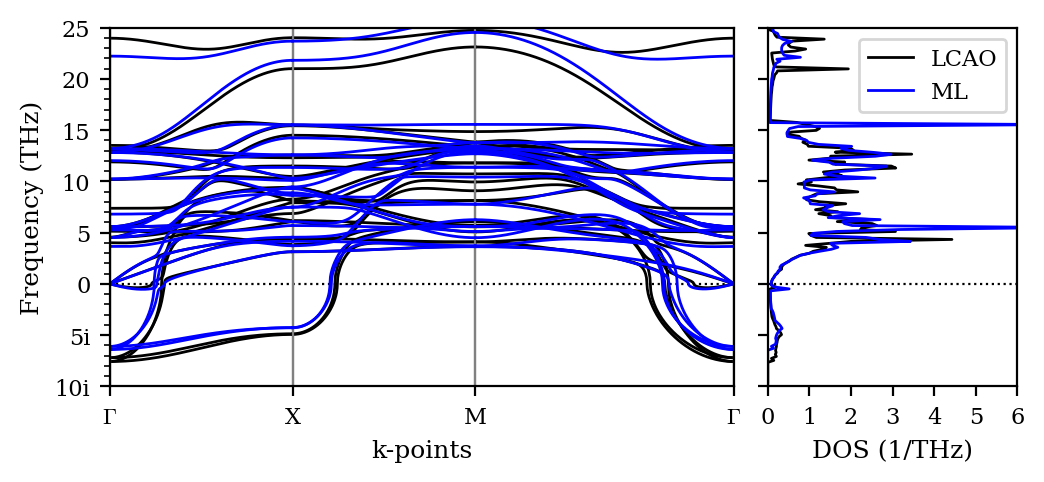

In [19]:
# Calculate phonons for the 1.5 unit cell slab structure using the trained NEP model
atoms = Perovskite('BaTiO3', bulk=False, dslab=1.5).atoms
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/1.5uc/0001/phonons/BaTiO3.yaml")
plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=1, bulk=False)

      Step     Time          Energy          fmax
BFGS:    0 13:18:56     -114.071960        2.528881
BFGS:    1 13:18:56     -114.292752        1.629271
BFGS:    2 13:18:56     -114.506075        0.947413
BFGS:    3 13:18:56     -114.560925        0.700696
BFGS:    4 13:18:56     -114.650800        0.446693
BFGS:    5 13:18:56     -114.663934        0.390141
BFGS:    6 13:18:56     -114.704913        0.308876
BFGS:    7 13:18:56     -114.712944        0.167119
BFGS:    8 13:18:56     -114.717598        0.151125
BFGS:    9 13:18:56     -114.720251        0.093878
BFGS:   10 13:18:56     -114.722083        0.076500
BFGS:   11 13:18:56     -114.722653        0.057561
BFGS:   12 13:18:56     -114.723039        0.058336
BFGS:   13 13:18:56     -114.723714        0.081022
BFGS:   14 13:18:56     -114.724771        0.093034
BFGS:   15 13:18:56     -114.725740        0.066965
BFGS:   16 13:18:56     -114.726092        0.023426
BFGS:   17 13:18:56     -114.726151        0.002485
BFGS:   18 13:

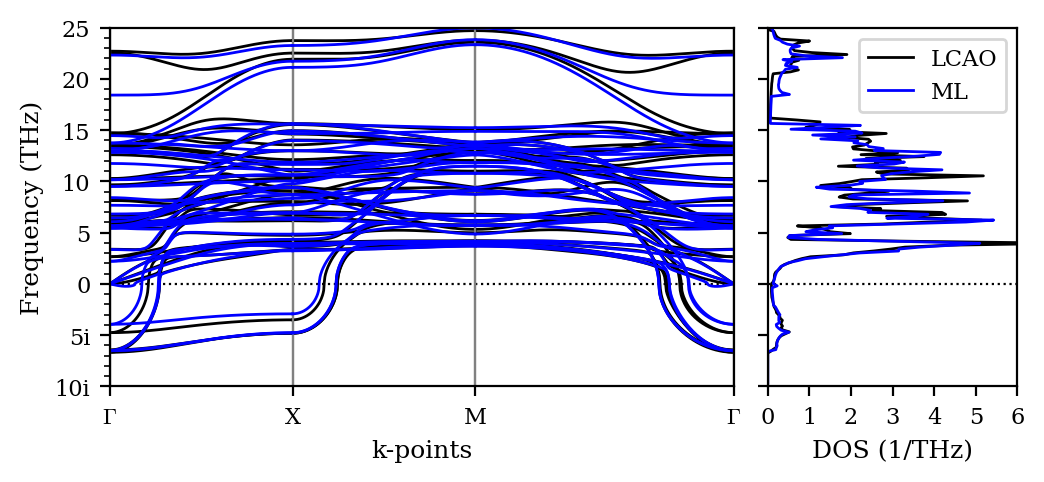

In [9]:
# Calculate phonons for the 2.5 unit cell slab structure using the trained NEP model
atoms = Perovskite('BaTiO3', bulk=False, dslab=2.5).atoms
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/2.5uc/0001/phonons/BaTiO3.yaml")
plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=1, bulk=False)

# Tests

In [13]:
from src.structure import Perovskite
perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms
calculator = CPUNEP('results/MLtest/nepmodel_split1/nep.txt')
atoms.calc = calculator
relax_structure(atoms, fmax=0.00001)

In [14]:
atoms.cell

Cell([[3.961134456663261, -1.739646449265033e-18, 2.3777005252795005e-18], [3.2816032633461203e-17, 3.9611344566632525, -4.53674797921587e-15], [4.013580058709373e-17, -4.467379310396215e-15, 3.9611344566632507]])

In [58]:
phonon_ML = get_force_constants(atoms, calculator, [2, 2, 2])

In [154]:
from src.phononcalc import get_phonon_dispersion, get_phonon_dos, get_phonon_pdos, order_labels
from src.frozenphonon import get_displacement, get_unstable_mode_groups
from src.phononASE import phonon_to_atoms
from src.plotsettings import PlotSettings
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from ase.io import read, write
from ase.visualize import view
import numpy as np
import pandas as pd

In [60]:
# Load the phonon calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")

In [164]:
def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'R': [0.5, 0.5, 0.5],
        'M': [0.5, 0.5, 0.0],
    }

    dd_dict = {
        'G': 1/n_points,
        'X': 1.5/n_points,
        'R': 5/n_points,
        'M': 3/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    energy = supercell_disp.get_potential_energy() / ncells

                    amplitudes.append(amp)
                    energies.append(energy)

                    amp += dd

                    tol = 50e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies
                })
                
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "q": q
                }

    return results


In [165]:
results = displace_imaginary_modes(phonon)

No unstable modes found at R
No unstable modes found at M


In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier


# ---------- Main plotting ----------

def plot_frozen_phonons(results, mirror=True):

    qpoints = sorted(results.keys())
    N = len(qpoints)

    fig, axes = plt.subplots(1, N, figsize=(4*N, 4), sharey=True)

    if N == 1:
        axes = [axes]

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, q in enumerate(qpoints):

        ax = axes[i]

        if q == "G":
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f"{q} point")

        color_idx = 0

        for g_id, modes in results[q].items():
            for mode_id, data in modes.items():

                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [160]:
from scipy.optimize import curve_fit

In [161]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Double well potentials
def U_harm(x, omega):
    return -1/2 * omega * x**2


def U_anharm(x, a, b):
    return -1/2 * a * x**2 + 1/4 * b * x**4


def plotDWs(formula, ids, bulk=True, Ncells=1, mirror=False):

    if isinstance(ids, str):
        ids = [ids]

    ytickmarks = np.arange(-10, 30, 5)

    # ---------- Structure path ----------
    if bulk:
        struc = f'bulk/{formula}'
    else:
        struc = f'slab/{formula}/{Ncells}uc'

    # ---------- Determine q-points ----------
    first_dir = os.path.join('results', struc, ids[0], 'frozen')

    q_points = [
        d for d in os.listdir(first_dir)
        if os.path.isdir(os.path.join(first_dir, d))
    ]

    N = len(q_points)

    # ---------- Colors ----------
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors = {id_: color_cycle[i % len(color_cycle)] for i, id_ in enumerate(ids)}

    # ---------- Create figure ----------
    fig, axes = plt.subplots(1, N, figsize=(3*N, 5), sharey='col')

    if N == 1:
        axes = [axes]

    PlotSettings().set_size(fig)
    plt.subplots_adjust(wspace=0.08)

    # ---------- Helper functions ----------

    def load_dw_data(id_, q):
        """Load all DW data for a given calculation id and q-point."""
        dir_q = os.path.join('results', struc, id_, 'frozen', q)

        if not os.path.exists(dir_q):
            return []

        datasets = []

        for mode in os.listdir(dir_q):

            dir_mode = os.path.join(dir_q, mode)

            if not os.path.isdir(dir_mode):
                continue

            try:
                with open(os.path.join(dir_mode, 'freq.txt')) as f:
                    label = f.read().strip()
            except FileNotFoundError:
                label = mode

            for deg in os.listdir(dir_mode):

                dir_deg = os.path.join(dir_mode, deg)

                if not os.path.isdir(dir_deg):
                    continue

                df = pd.read_csv(os.path.join(dir_deg, 'energies.csv'))

                datasets.append((label, df))

        return datasets


    def get_fit(df):

        x = df['Amplitude'].to_numpy()
        y = df['Energy'].to_numpy() * 1000

        y0 = df[df['Amplitude'] == 0]['Energy'].iloc[0] * 1000
        y = y - y0

        xfit = np.linspace(0, max(x), 1000)

        popt, _ = curve_fit(U_anharm, x, y)

        yfit = U_anharm(xfit, *popt)

        return x, y, xfit, yfit


    def plot_curve(ax, x, y, xfit, yfit, color, label=None):

        if mirror:
            xfit = np.concatenate((-xfit[::-1], xfit))
            yfit = np.concatenate((yfit[::-1], yfit))

        #ax.plot(x, y, '.', markersize=4, color=color, label=label)
        ax.plot(xfit, yfit, '-', lw=1, color=color, label=label)

        ax.plot(0, 0, 'r.', markersize=4)

        dx = 0.5 if max(xfit) < 2 else 1
        xtickmarks = np.arange(0, max(xfit), dx)

        xticklabels = np.where(
            xtickmarks % 1 == 0,
            xtickmarks.astype(int).astype(str),
            xtickmarks.astype(str)
        )

        ax.set_xticks(xtickmarks, xticklabels)
        ax.set_yticks(ytickmarks, ytickmarks.astype(str))

        ax.set_xlim(min(xfit), max(xfit))
        ax.set_ylim(-20, 25)

        PlotSettings().set_style_ax(ax, gridlines=True)

    # ---------- Main plotting loop ----------

    for i, q in enumerate(q_points):

        ax = axes[i]

        if q == 'G':
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f'{q} point')

        for id_ in ids:

            datasets = load_dw_data(id_, q)

            for j, (label, df) in enumerate(datasets):

                x, y, xfit, yfit = get_fit(df)

                plot_curve(
                    ax,
                    x, y,
                    xfit, yfit,
                    colors[id_],
                    label=f'{id_}: {label}' if j == 0 else None
                )

        ax.legend(loc='upper center')

        ax.set_xlabel(f'$Q_{i+1}$ (amu$^{{1/2}}$Å)')

        if i != 0:
            ax.set_yticklabels([])

    axes[0].set_ylabel(r'$\Delta$ Energy (meV/u.c.)')

    axes[-1].tick_params(axis='y', labelright=True, labelleft=False)

    plt.show()

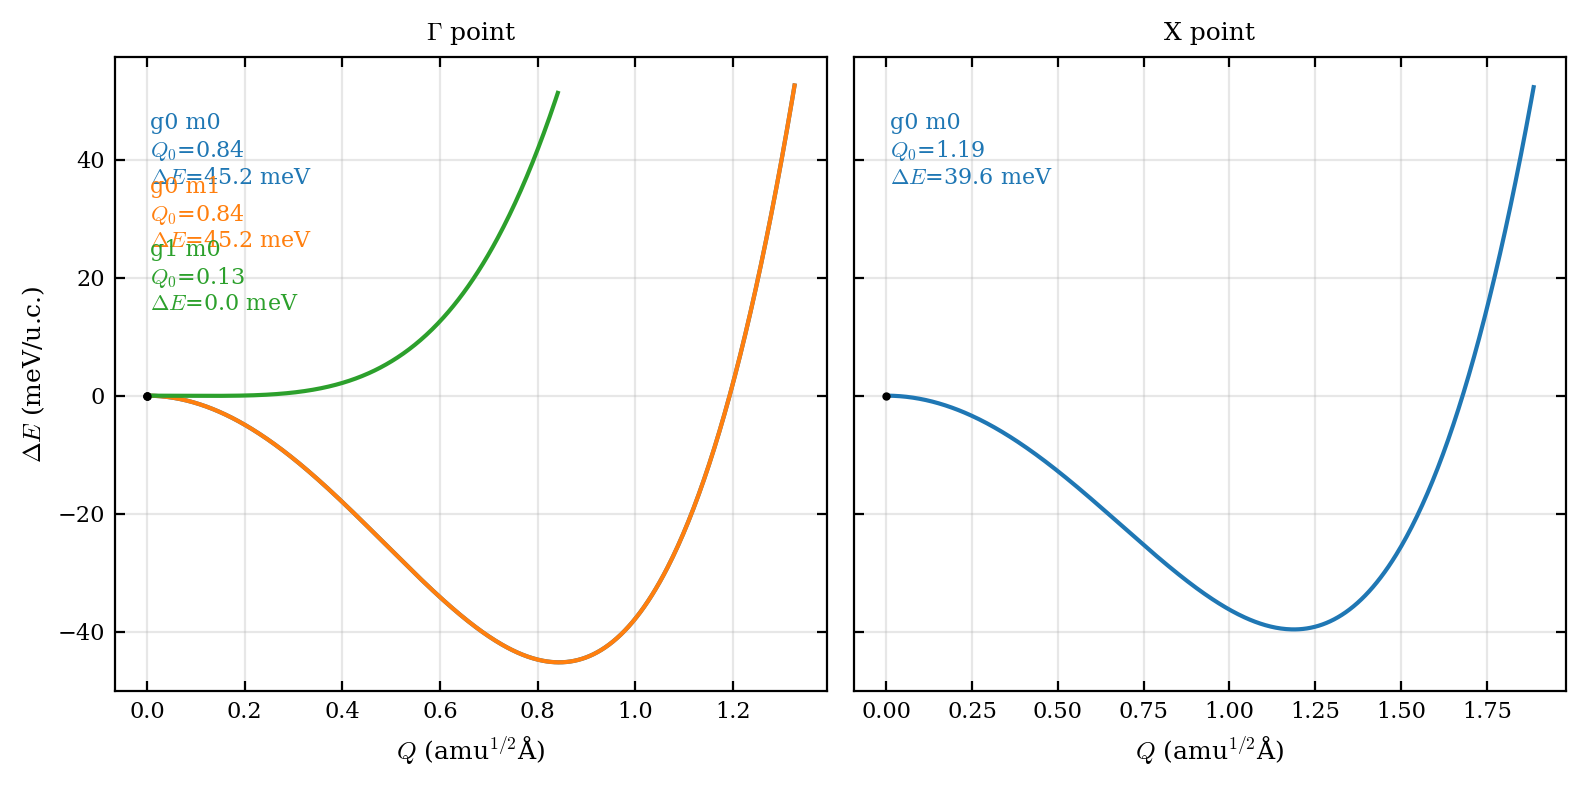

In [162]:
plot_frozen_phonons(results, mirror=False)

0


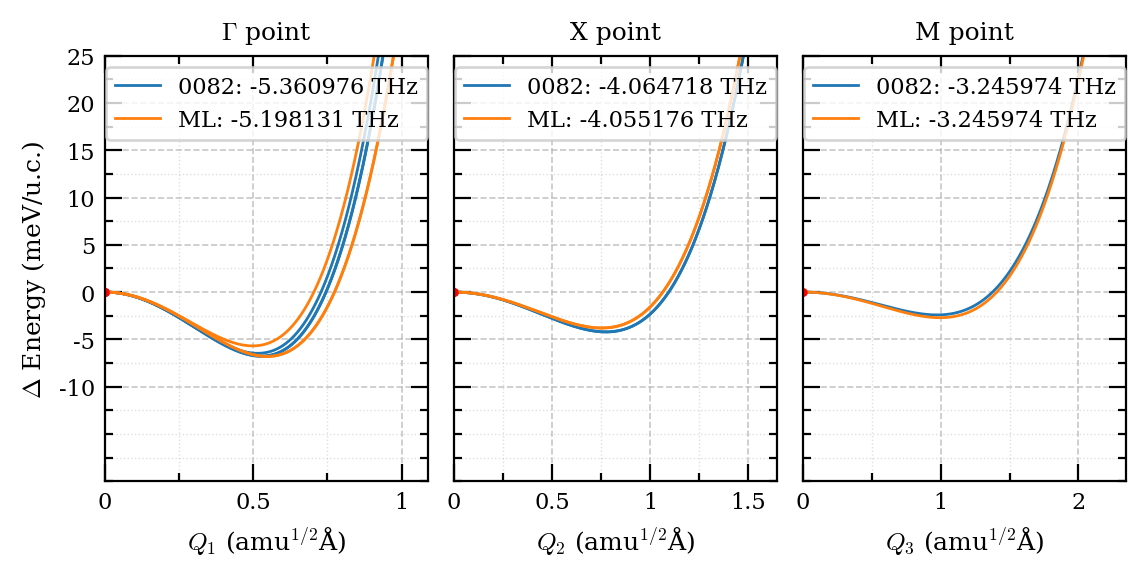

In [65]:
plotDWs('BaTiO3', ['0082', 'ML'])